# Australian CPI Forecasting EDA

This notebook performs a screening-stage EDA pass over the curated quarterly macro table for SARIMA/Elastic Net modelling. Statistical screens are treated as indicative only because the sample is small and several predictors have early missingness. Forecast-origin availability is represented as an explicit assumption set, not as a fact derived from the curated schema.

The EDA window ends at the forecast origin (`svar.FORECAST_ORIGIN_PIN`, 2025Q4). Quarters after it are in the curated table only so the pinned forecasts can be benchmarked against realised outcomes; nothing below sees them.

In [1]:
from pathlib import Path
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.platform_validation import validate_curated_with_pandera
from src.eda_export import EDA_END_QUARTER, restrict_to_eda_window
from src.transform import latest_dataset_path
from src.validation import validate_curated_dataset

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = ROOT / 'data' / 'curated' / 'quarterly_macro_features.csv'
AVAILABILITY_PATH = ROOT / 'data' / 'metadata' / 'series_availability.csv'
TARGET = 'cpi_yoy'
MAX_LAG = 4
SIGNAL_P_THRESHOLD = 0.10
SIGNAL_CORR_THRESHOLD = 0.20
MATERIAL_MISSING_THRESHOLD = 0.20
VIF_THRESHOLD = 10.0
CPI_FAMILY_BASE_COLS = [
    'cpi_qoq',
    'cpi_yoy',
    'trimmed_mean_cpi_qoq',
    'trimmed_mean_cpi_yoy',
]
CPI_DERIVED_DIAGNOSTIC_COLS = ['headline_trimmed_mean_yoy_gap']
CPI_DIAGNOSTIC_BASE_COLS = [
    'cpi_qoq',
    'trimmed_mean_cpi_qoq',
    'trimmed_mean_cpi_yoy',
    'headline_trimmed_mean_yoy_gap',
]
CPI_FAMILY_LAGGED_FEATURES = [
    'cpi_yoy_lag1',
    'cpi_yoy_lag4',
    'trimmed_mean_cpi_yoy_lag1',
    'trimmed_mean_cpi_yoy_lag4',
]

## 1. Data Integrity Checks

In [2]:
# EDA sees only quarters up to the forecast origin; later quarters are held out for benchmarking.
df = restrict_to_eda_window(pd.read_csv(DATA_PATH))
df['quarter_period'] = pd.PeriodIndex(df['quarter'], freq='Q')
df['quarter_start'] = df['quarter_period'].dt.to_timestamp(how='start')
df = df.sort_values('quarter_period').reset_index(drop=True)

# src.features owns these rate-change transforms for future curated rebuilds.
# Keep this compatibility block so the current checked-in curated CSV can still
# execute before the generated dataset is refreshed. Rate levels are percentages,
# so differences are percentage-point moves rather than proportional log changes.
RATE_CHANGE_LAG_MAP = {
    'cash_rate': [1],
    'unemployment_rate': [1, 2],
}
for source_col, lags in RATE_CHANGE_LAG_MAP.items():
    if source_col not in df:
        continue
    change_col = f'{source_col}_change'
    df[change_col] = df[source_col].diff()
    for lag in lags:
        df[f'{change_col}_lag{lag}'] = df[change_col].shift(lag)

if {'cpi_yoy', 'trimmed_mean_cpi_yoy'}.issubset(df.columns):
    df['headline_trimmed_mean_yoy_gap'] = df['cpi_yoy'] - df['trimmed_mean_cpi_yoy']

df_model = df.drop(columns=['quarter_period', 'quarter_start'])

schema = pd.DataFrame({'column': df_model.columns, 'dtype': df_model.dtypes.astype(str).values})
display(schema)
display(df_model.head())

validation_records = [record.as_dict() for record in validate_curated_dataset(df_model)]
validation_records.append(validate_curated_with_pandera(df_model).as_dict())
validation_summary = pd.DataFrame(validation_records)
display(validation_summary.head(16))

quarters = df['quarter_period']
expected_quarters = pd.period_range(quarters.min(), quarters.max(), freq='Q')
integrity_summary = pd.DataFrame([
    {'check': 'row_count', 'value': len(df)},
    {'check': 'column_count', 'value': len(df_model.columns)},
    {'check': 'start_quarter', 'value': str(quarters.min())},
    {'check': 'end_quarter', 'value': str(quarters.max())},
    {'check': 'duplicate_quarters', 'value': int(df['quarter'].duplicated().sum())},
    {'check': 'missing_quarters', 'value': int(len(expected_quarters.difference(quarters)))},
    {'check': 'is_sorted', 'value': bool(quarters.is_monotonic_increasing)},
])
display(integrity_summary)

,column,dtype
0,quarter,object
1,cpi_qoq,float64
2,cpi_yoy,float64
3,trimmed_mean_cpi_qoq,float64
4,trimmed_mean_cpi_yoy,float64
5,unemployment_rate,float64
6,unemployment_rate_change,float64
7,cash_rate,float64
8,cash_rate_change,float64
9,wage_price_index,float64


,quarter,cpi_qoq,cpi_yoy,trimmed_mean_cpi_qoq,trimmed_mean_cpi_yoy,unemployment_rate,unemployment_rate_change,cash_rate,cash_rate_change,wage_price_index,wpi_growth,producer_price_index,ppi_growth,commodity_price_index,commodity_growth,wti_price,wti_growth,brent_price,brent_growth,aud_usd,aud_usd_change,household_spending,household_spending_growth,inflation_expectations_business,cpi_yoy_lag1,cpi_yoy_lag4,trimmed_mean_cpi_yoy_lag1,trimmed_mean_cpi_yoy_lag4,cash_rate_lag1,cash_rate_lag2,cash_rate_lag4,unemployment_rate_lag1,unemployment_rate_lag2,unemployment_rate_lag4,wpi_growth_lag1,wpi_growth_lag2,ppi_growth_lag1,ppi_growth_lag2,commodity_growth_lag1,wti_growth_lag1,brent_growth_lag1,aud_usd_change_lag1,cash_rate_change_lag1,unemployment_rate_change_lag1,unemployment_rate_change_lag2,household_spending_growth_lag1,inflation_expectations_business_lag1,covid_shock_down_lag0,covid_shock_rebound_lag1,headline_trimmed_mean_yoy_gap
0,1995Q1,1.6,3.9,0.5,2.2,8.765438,NaN,7.5,NaN,NaN,NaN,NaN,NaN,29.996283,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1.7
1,1995Q2,1.3,4.5,0.9,2.5,8.364857,-0.400582,7.5,0.0,NaN,NaN,NaN,NaN,31.011010,3.382842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.39,3.9,NaN,2.2,NaN,7.5,NaN,NaN,8.765438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.02,0,0,2.0
2,1995Q3,1.2,5.1,1.0,2.9,8.370623,0.005766,7.5,0.0,NaN,NaN,NaN,NaN,30.733831,-0.893806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.28,4.5,NaN,2.5,NaN,7.5,7.5,NaN,8.364857,8.765438,NaN,NaN,NaN,NaN,NaN,3.382842,NaN,NaN,NaN,0.0,-0.400582,NaN,NaN,4.39,0,0,2.2
3,1995Q4,0.8,4.9,0.7,3.1,8.390929,0.020306,7.5,0.0,NaN,NaN,NaN,NaN,30.162208,-1.859915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.58,5.1,NaN,2.9,NaN,7.5,7.5,NaN,8.370623,8.364857,NaN,NaN,NaN,NaN,NaN,-0.893806,NaN,NaN,NaN,0.0,0.005766,-0.400582,NaN,3.28,0,0,1.8
4,1996Q1,0.5,3.8,0.6,3.2,8.400115,0.009187,7.5,0.0,NaN,NaN,NaN,NaN,29.976517,-0.615640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.26,4.9,3.9,3.1,2.2,7.5,7.5,7.5,8.390929,8.370623,8.765438,NaN,NaN,NaN,NaN,-1.859915,NaN,NaN,NaN,0.0,0.020306,0.005766,NaN,2.58,0,0,0.6


,dataset,status,rows,columns,start_date,end_date,missing_values,duplicate_dates,notes
0,curated_quarterly_macro_features,PASS,124,50,1995Q1,2025Q4,763,0,ok
1,curated_column:cpi_qoq,PASS,124,1,1995Q1,2025Q4,0,0,ok
2,curated_column:cpi_yoy,PASS,124,1,1995Q1,2025Q4,0,0,ok
3,curated_column:trimmed_mean_cpi_qoq,PASS,124,1,1995Q1,2025Q4,0,0,ok
4,curated_column:trimmed_mean_cpi_yoy,PASS,124,1,1995Q1,2025Q4,0,0,ok
5,curated_column:unemployment_rate,PASS,124,1,1995Q1,2025Q4,0,0,ok
6,curated_column:unemployment_rate_change,PASS,123,1,1995Q1,2025Q4,1,0,ok
7,curated_column:cash_rate,PASS,124,1,1995Q1,2025Q4,0,0,ok
8,curated_column:cash_rate_change,PASS,123,1,1995Q1,2025Q4,1,0,ok
9,curated_column:wage_price_index,PASS,114,1,1995Q1,2025Q4,10,0,ok


,check,value
0,row_count,124
1,column_count,50
2,start_quarter,1995Q1
3,end_quarter,2025Q4
4,duplicate_quarters,0
5,missing_quarters,0
6,is_sorted,True


## 2. Missing Values And Coverage

In [3]:
def first_last_non_null_date(frame: pd.DataFrame, column: str) -> tuple[str | None, str | None]:
    mask = frame[column].notna()
    if not mask.any():
        return None, None
    return str(frame.loc[mask, 'quarter_period'].iloc[0]), str(frame.loc[mask, 'quarter_period'].iloc[-1])


def coverage_class(coverage_pct: float) -> str:
    if coverage_pct >= 0.95:
        return 'core_long_sample_candidate'
    if coverage_pct >= 0.80:
        return 'shorter_sample_candidate'
    if coverage_pct >= 0.50:
        return 'limited_sample_candidate'
    return 'exclude_low_coverage'


sample_start = str(df['quarter_period'].min())
coverage_rows = []
for column in df_model.columns:
    if column == 'quarter':
        continue
    first_non_null, last_non_null = first_last_non_null_date(df, column)
    missing_count = int(df[column].isna().sum())
    available_observations = int(df[column].notna().sum())
    missing_pct = missing_count / len(df)
    coverage_pct = available_observations / len(df)
    late_start_reduces_sample = first_non_null not in {None, sample_start}
    substantial_missingness = missing_pct >= MATERIAL_MISSING_THRESHOLD
    coverage_rows.append({
        'variable': column,
        'available_observations': available_observations,
        'non_null_rows': available_observations,
        'missing_count': missing_count,
        'missing_pct': missing_pct,
        'coverage_pct': coverage_pct,
        'start_quarter': sample_start,
        'first_non_null': first_non_null,
        'last_non_null': last_non_null,
        'late_start_reduces_estimation_sample': bool(late_start_reduces_sample),
        'substantial_missingness_warning': bool(substantial_missingness),
        # Backward-compatible name used later in the notebook; this now means
        # genuinely substantial missingness, not merely starting after 1995Q1.
        'material_early_missingness': bool(substantial_missingness),
        'coverage_class': coverage_class(coverage_pct),
    })

coverage = pd.DataFrame(coverage_rows).sort_values(['missing_pct', 'variable'], ascending=[False, True])
display(coverage)
display(coverage.loc[coverage['substantial_missingness_warning'], ['variable', 'missing_pct', 'coverage_pct', 'first_non_null', 'last_non_null', 'coverage_class']])

,variable,available_observations,non_null_rows,missing_count,missing_pct,coverage_pct,start_quarter,first_non_null,last_non_null,late_start_reduces_estimation_sample,substantial_missingness_warning,material_early_missingness,coverage_class
44,household_spending_growth_lag1,52,52,72,0.580645,0.419355,1995Q1,2013Q1,2025Q4,True,True,True,exclude_low_coverage
21,household_spending_growth,53,53,71,0.572581,0.427419,1995Q1,2012Q4,2025Q4,True,True,True,exclude_low_coverage
20,household_spending,54,54,70,0.564516,0.435484,1995Q1,2012Q3,2025Q4,True,True,True,exclude_low_coverage
40,aud_usd_change_lag1,62,62,62,0.500000,0.500000,1995Q1,2010Q3,2025Q4,True,True,True,limited_sample_candidate
19,aud_usd_change,63,63,61,0.491935,0.508065,1995Q1,2010Q2,2025Q4,True,True,True,limited_sample_candidate
18,aud_usd,64,64,60,0.483871,0.516129,1995Q1,2010Q1,2025Q4,True,True,True,limited_sample_candidate
39,brent_growth_lag1,72,72,52,0.419355,0.580645,1995Q1,2008Q1,2025Q4,True,True,True,limited_sample_candidate
17,brent_growth,73,73,51,0.411290,0.588710,1995Q1,2007Q4,2025Q4,True,True,True,limited_sample_candidate
16,brent_price,74,74,50,0.403226,0.596774,1995Q1,2007Q3,2025Q4,True,True,True,limited_sample_candidate
38,wti_growth_lag1,100,100,24,0.193548,0.806452,1995Q1,2001Q1,2025Q4,True,False,False,shorter_sample_candidate


,variable,missing_pct,coverage_pct,first_non_null,last_non_null,coverage_class
44,household_spending_growth_lag1,0.580645,0.419355,2013Q1,2025Q4,exclude_low_coverage
21,household_spending_growth,0.572581,0.427419,2012Q4,2025Q4,exclude_low_coverage
20,household_spending,0.564516,0.435484,2012Q3,2025Q4,exclude_low_coverage
40,aud_usd_change_lag1,0.500000,0.500000,2010Q3,2025Q4,limited_sample_candidate
19,aud_usd_change,0.491935,0.508065,2010Q2,2025Q4,limited_sample_candidate
18,aud_usd,0.483871,0.516129,2010Q1,2025Q4,limited_sample_candidate
39,brent_growth_lag1,0.419355,0.580645,2008Q1,2025Q4,limited_sample_candidate
17,brent_growth,0.411290,0.588710,2007Q4,2025Q4,limited_sample_candidate
16,brent_price,0.403226,0.596774,2007Q3,2025Q4,limited_sample_candidate


## 3. CPI Target Inspection

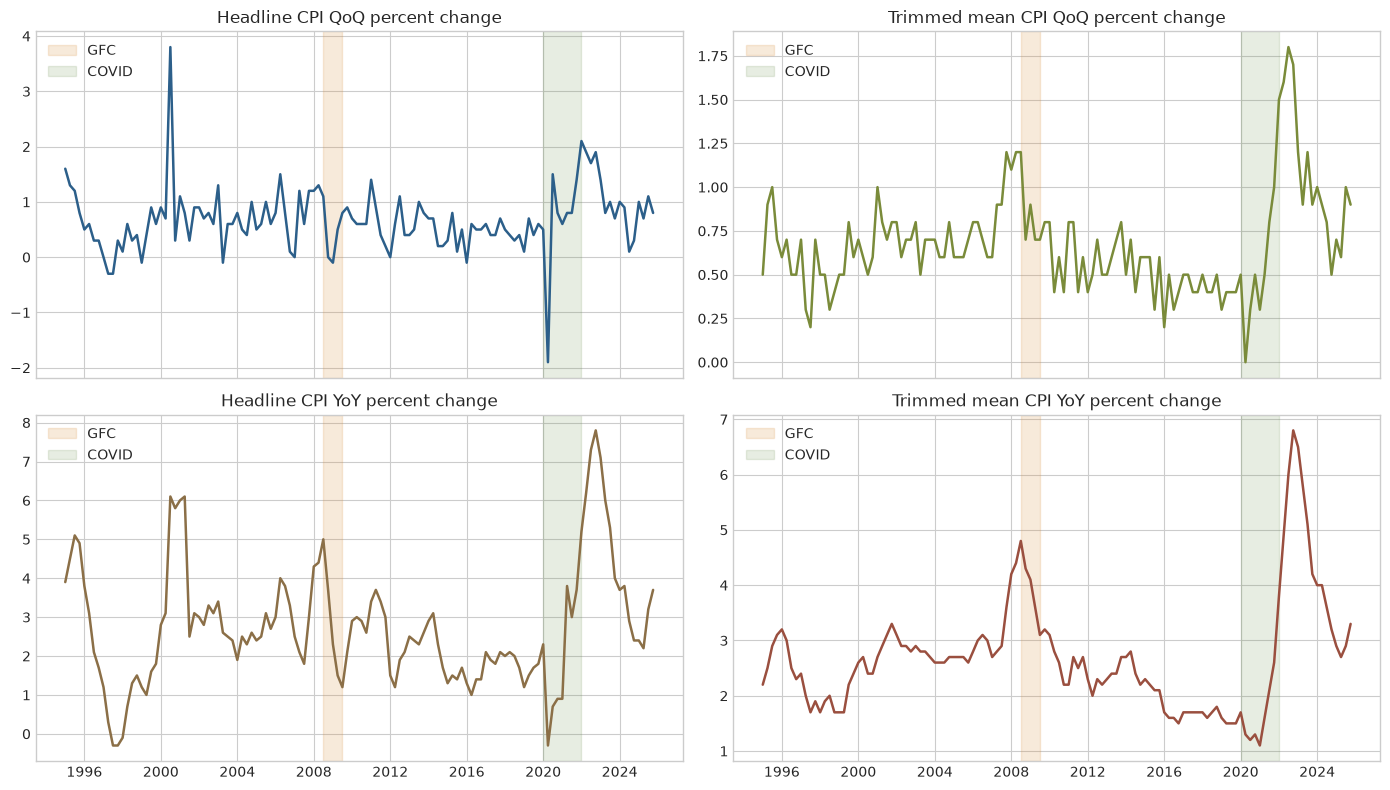

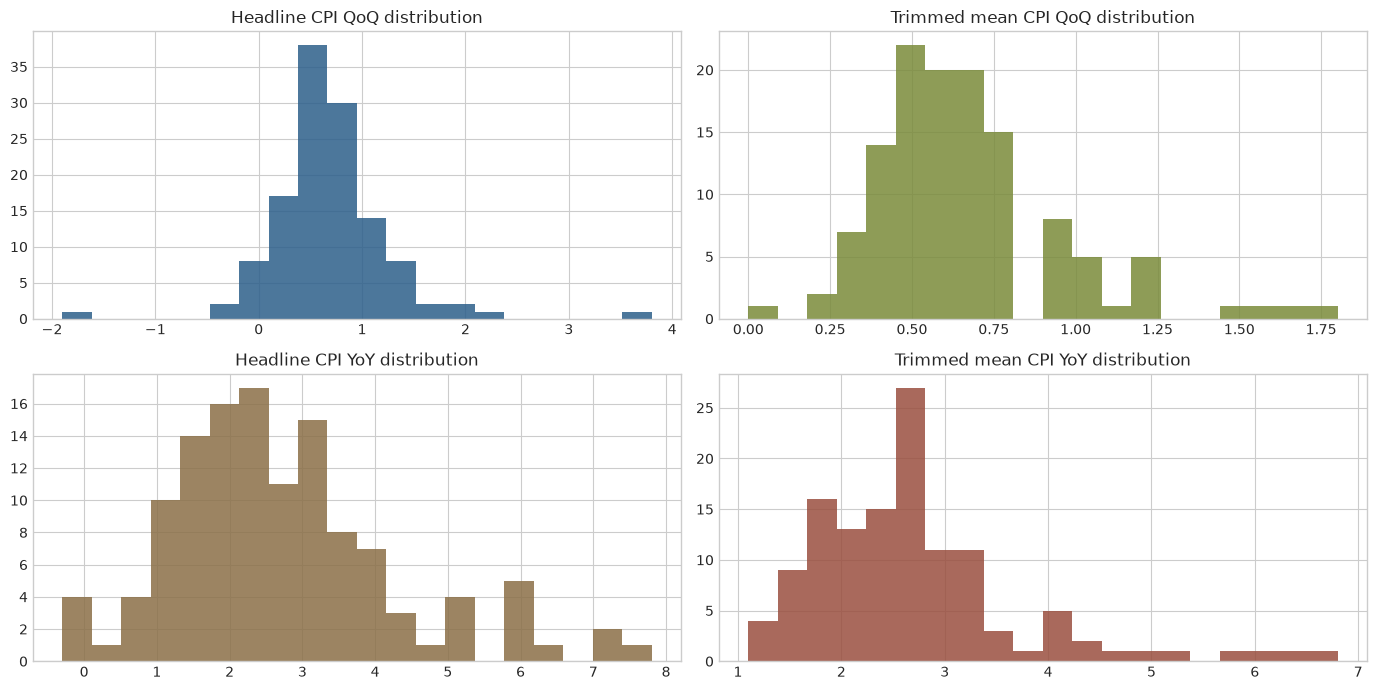

,quarter,metric,value,z_score
0,2000Q3,cpi_qoq,3.8,5.41
1,2020Q2,cpi_qoq,-1.9,-4.45
2,2022Q1,trimmed_mean_cpi_qoq,1.5,2.88
3,2022Q2,trimmed_mean_cpi_qoq,1.6,3.23
4,2022Q3,trimmed_mean_cpi_qoq,1.8,3.92
5,2022Q4,trimmed_mean_cpi_qoq,1.7,3.57
6,2022Q3,cpi_yoy,7.3,2.96
7,2022Q4,cpi_yoy,7.8,3.28
8,2023Q1,cpi_yoy,7.1,2.83
9,2022Q3,trimmed_mean_cpi_yoy,6.0,3.23


In [4]:
plot_specs = [
    ('cpi_qoq', 'Headline CPI QoQ percent change', '#2c5f8a'),
    ('trimmed_mean_cpi_qoq', 'Trimmed mean CPI QoQ percent change', '#7a8b3a'),
    ('cpi_yoy', 'Headline CPI YoY percent change', '#8b6f47'),
    ('trimmed_mean_cpi_yoy', 'Trimmed mean CPI YoY percent change', '#9a4f3f'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.reshape(-1)
for ax, (column, title, color) in zip(axes, plot_specs):
    ax.plot(df['quarter_start'], df[column], color=color, linewidth=1.8)
    ax.set_title(title)
    ax.axvspan(pd.Period('2008Q3', freq='Q').to_timestamp(), pd.Period('2009Q3', freq='Q').to_timestamp(), color='#d88c36', alpha=0.18, label='GFC')
    ax.axvspan(pd.Period('2020Q1', freq='Q').to_timestamp(), pd.Period('2022Q1', freq='Q').to_timestamp(), color='#6a8f4e', alpha=0.16, label='COVID')
    ax.legend(loc='best')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.reshape(-1)
for ax, (column, title, color) in zip(axes, plot_specs):
    df[column].dropna().hist(ax=ax, bins=20, color=color, alpha=0.85)
    ax.set_title(title.replace('percent change', 'distribution'))
fig.tight_layout()
plt.show()

outlier_rows = []
for column, _, _ in plot_specs:
    series = df[column]
    z_score = (series - series.mean()) / series.std(ddof=0)
    flagged = df.loc[z_score.abs() >= 2.5, ['quarter', column]].copy()
    flagged['metric'] = column
    flagged['z_score'] = z_score.loc[flagged.index].round(2)
    outlier_rows.append(flagged[['quarter', 'metric', column, 'z_score']].rename(columns={column: 'value'}))
outliers = pd.concat(outlier_rows, ignore_index=True) if outlier_rows else pd.DataFrame()
display(outliers)

### CPI Seasonal Decomposition And Autocorrelation Diagnostics

These diagnostics extend the CPI target inspection. STL separates the CPI index into trend, quarterly seasonal, and residual components; ACF/PACF plots then show whether CPI inflation and differenced CPI retain serial dependence that later SARIMA order selection should consider.

The modelling target `cpi_yoy` is already a four-quarter transformation: `CPI_YoY_t = (CPI_t / CPI_{t-4} - 1) * 100`. Adjacent YoY observations share overlapping CPI observations, so persistence in the ACF is partly mechanical and should not be interpreted as purely an autoregressive economic mechanism. Quarterly data also does not automatically imply `D = 1`; seasonal and non-seasonal SARIMA specifications should be compared with rolling-origin validation.

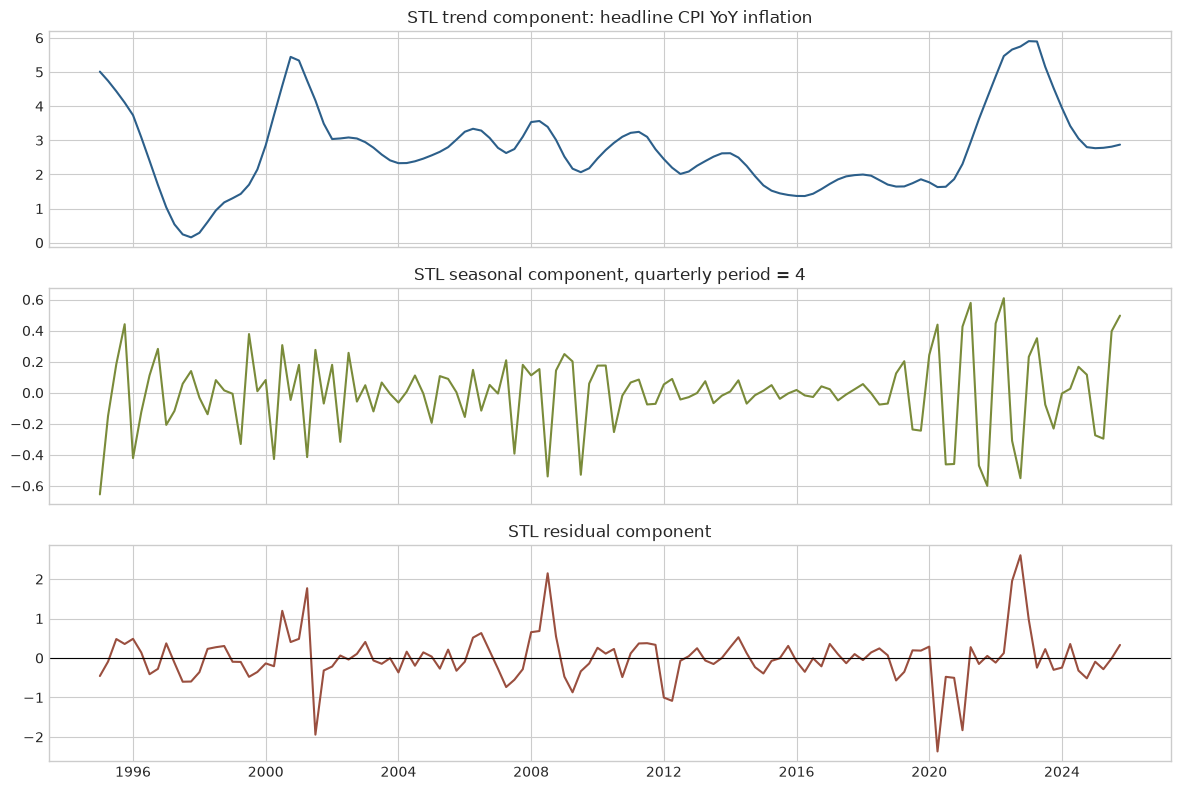

,series,stl_period_quarters,seasonal_strength,trend_strength,n_obs,interpretation
0,cpi_yoy,4,0.000,0.842,124,STL now decomposes the ABS SA headline growth-...
1,cpi_qoq,4,0.000,0.309,124,QoQ seasonality is closer to the quarterly inf...
2,trimmed_mean_cpi_yoy,4,0.000,0.875,124,Trimmed-mean YoY decomposition checks whether ...
3,trimmed_mean_cpi_qoq,4,0.063,0.704,124,QoQ seasonality is closer to the quarterly inf...


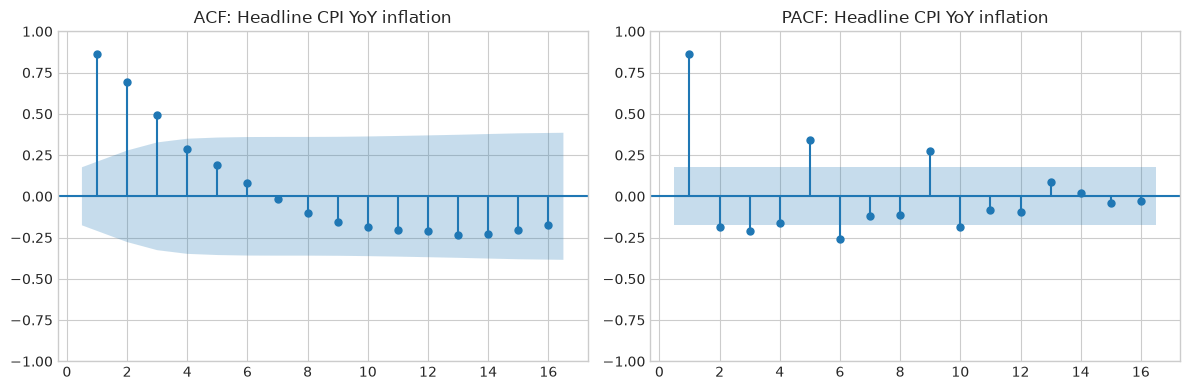

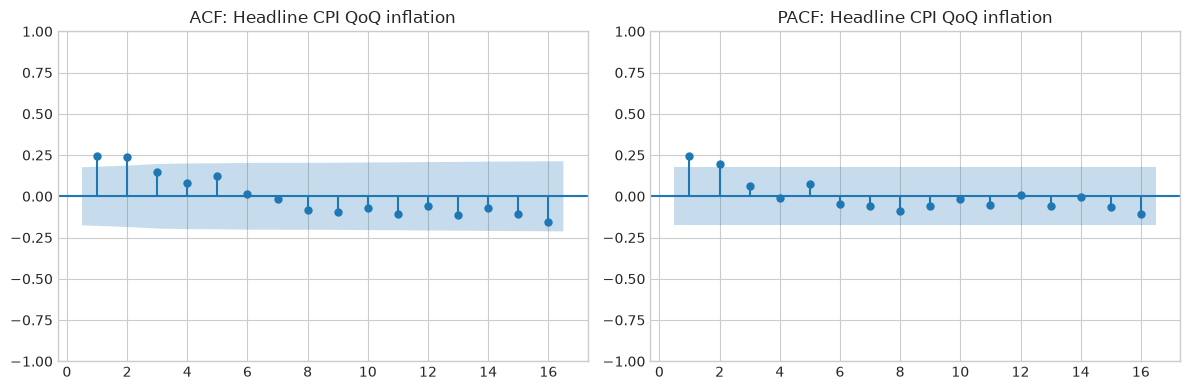

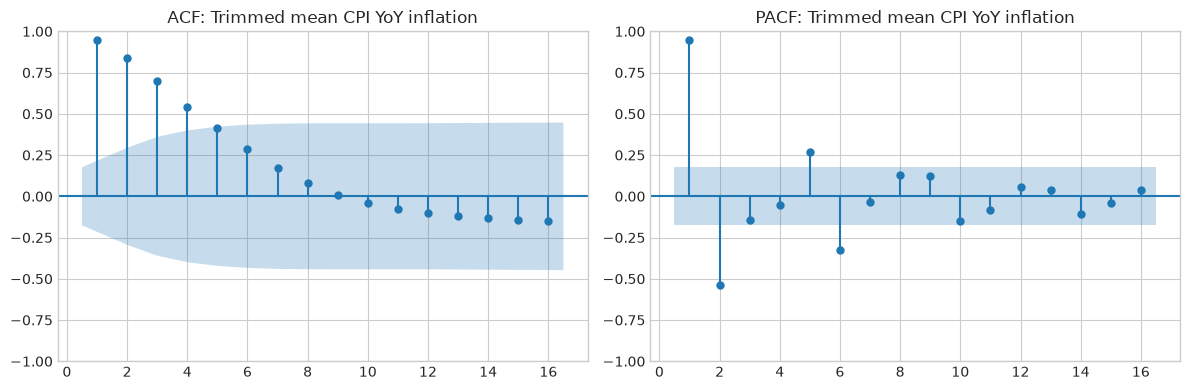

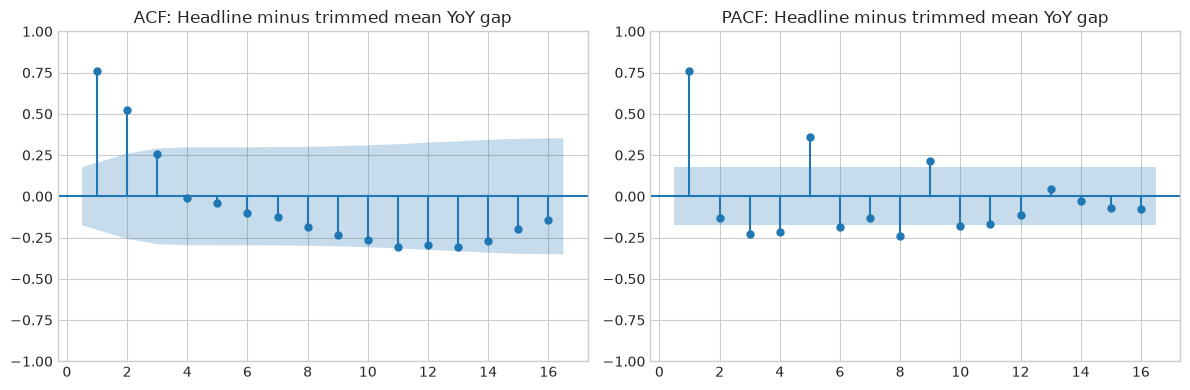

The STL decomposition now runs on headline CPI YoY inflation because `cpi_index` is no longer part of the curated ETL output. This is a growth-rate decomposition, not the prior level-series decomposition, so seasonal and trend strengths should be interpreted as properties of inflation rates. ACF/PACF patterns remain visual order-selection aids only; formal model choice still belongs to rolling-origin evaluation.

In [5]:
def stl_strength_summary(series: pd.Series, label: str) -> dict[str, object]:
    cleaned = series.dropna()
    result = STL(cleaned, period=4, robust=True).fit()
    seasonal_strength = max(0, 1 - np.nanvar(result.resid) / np.nanvar(result.resid + result.seasonal))
    trend_strength = max(0, 1 - np.nanvar(result.resid) / np.nanvar(result.resid + result.trend))
    return {
        'series': label,
        'stl_period_quarters': 4,
        'seasonal_strength': seasonal_strength,
        'trend_strength': trend_strength,
        'n_obs': int(len(cleaned)),
        'stl_result': result,
    }

cpi_stl_series = df.set_index('quarter_start')['cpi_yoy'].dropna()
stl_result = STL(cpi_stl_series, period=4, robust=True).fit()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(stl_result.trend.index, stl_result.trend, color='#2c5f8a')
axes[0].set_title('STL trend component: headline CPI YoY inflation')
axes[1].plot(stl_result.seasonal.index, stl_result.seasonal, color='#7a8b3a')
axes[1].set_title('STL seasonal component, quarterly period = 4')
axes[2].plot(stl_result.resid.index, stl_result.resid, color='#9a4f3f')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('STL residual component')
fig.tight_layout()
plt.show()

stl_strength_rows = [
    stl_strength_summary(df.set_index('quarter_start')[column], column)
    for column in ['cpi_yoy', 'cpi_qoq', 'trimmed_mean_cpi_yoy', 'trimmed_mean_cpi_qoq']
]
seasonality_summary = pd.DataFrame([
    {key: value for key, value in row.items() if key != 'stl_result'}
    for row in stl_strength_rows
])
seasonality_summary['interpretation'] = np.select(
    [
        seasonality_summary['series'].eq('cpi_yoy'),
        seasonality_summary['series'].eq('trimmed_mean_cpi_yoy'),
        seasonality_summary['series'].str.endswith('_qoq'),
    ],
    [
        'STL now decomposes the ABS SA headline growth-rate target, not a CPI level index.',
        'Trimmed-mean YoY decomposition checks whether underlying inflation has a different low-frequency profile.',
        'QoQ seasonality is closer to the quarterly inflation-rate series used in differenced SARIMA diagnostics.',
    ],
    default='',
)
display(seasonality_summary.round(3))

acf_pacf_series = {
    'Headline CPI YoY inflation': df.set_index('quarter_start')['cpi_yoy'].dropna(),
    'Headline CPI QoQ inflation': df.set_index('quarter_start')['cpi_qoq'].dropna(),
    'Trimmed mean CPI YoY inflation': df.set_index('quarter_start')['trimmed_mean_cpi_yoy'].dropna(),
    'Headline minus trimmed mean YoY gap': df.set_index('quarter_start')['headline_trimmed_mean_yoy_gap'].dropna(),
}

for title, series in acf_pacf_series.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    safe_lags = min(16, max(1, len(series) // 2 - 1))
    plot_acf(series, lags=safe_lags, ax=axes[0], zero=False)
    plot_pacf(series, lags=safe_lags, ax=axes[1], zero=False, method='ywm')
    axes[0].set_title(f'ACF: {title}')
    axes[1].set_title(f'PACF: {title}')
    fig.tight_layout()
    plt.show()

display(Markdown('The STL decomposition now runs on headline CPI YoY inflation because `cpi_index` is no longer part of the curated ETL output. This is a growth-rate decomposition, not the prior level-series decomposition, so seasonal and trend strengths should be interpreted as properties of inflation rates. ACF/PACF patterns remain visual order-selection aids only; formal model choice still belongs to rolling-origin evaluation.'))

## 4. External Variable Inspection

These plots z-score the raw curated predictor columns against CPI YoY for visual inspection only. Use the stationarity-aware CCF and Granger tables below for correlation evidence.

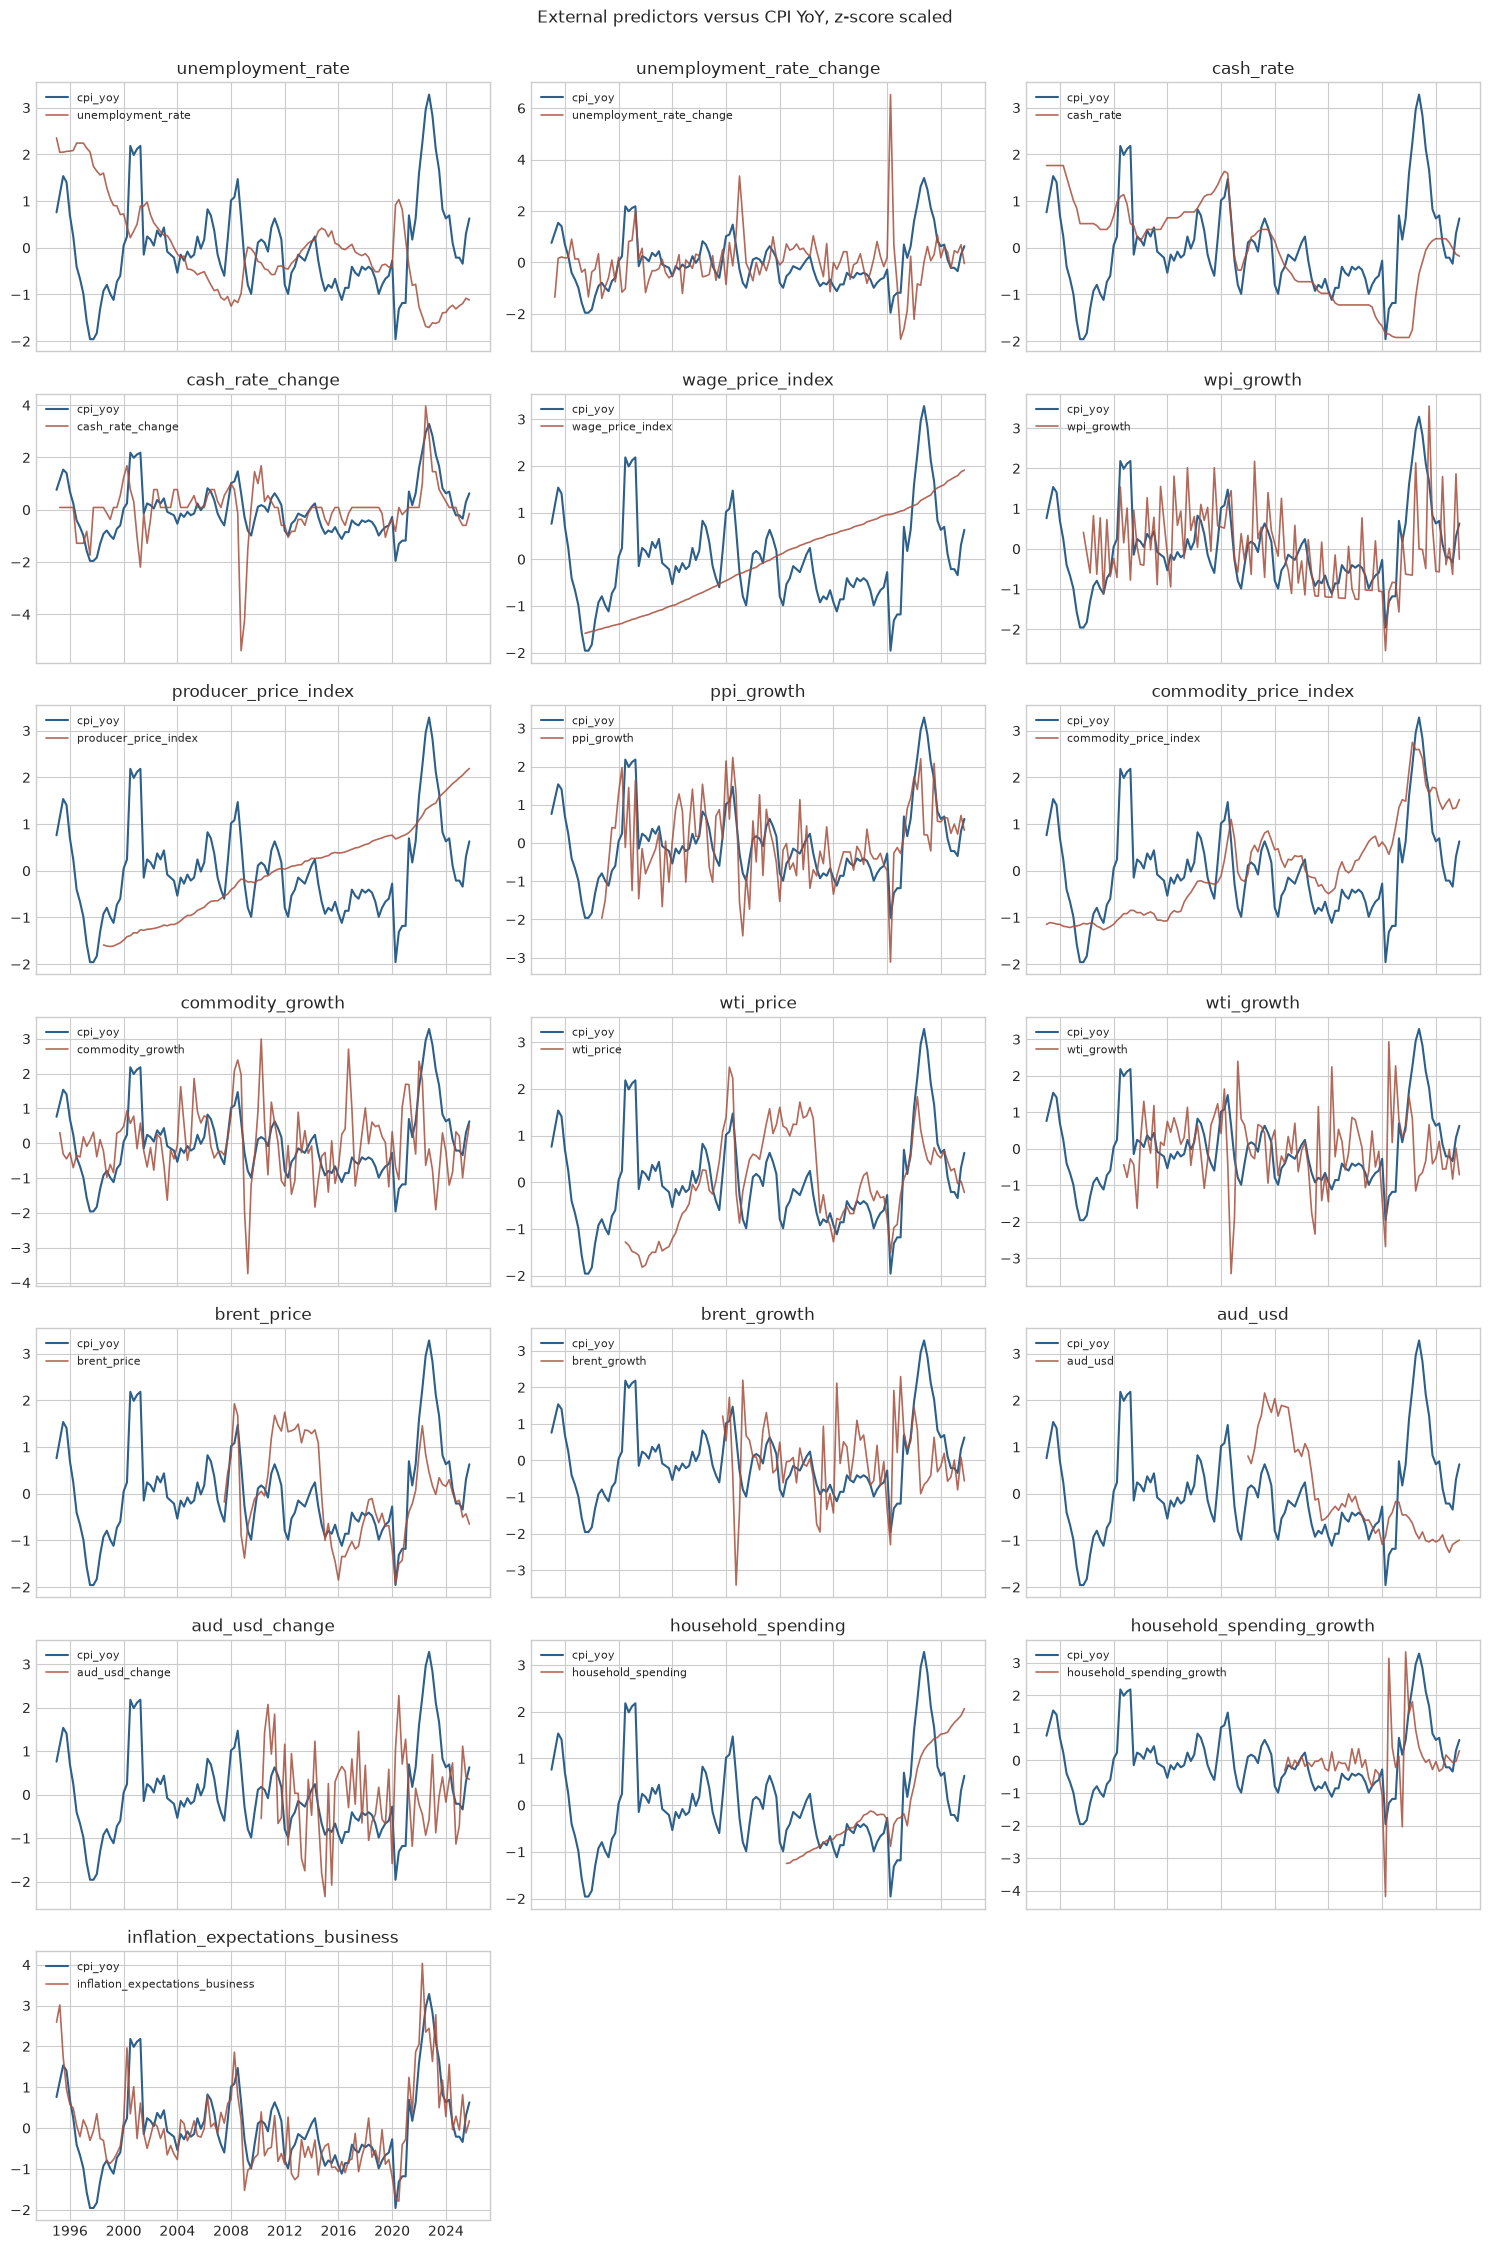

,external_base_variable
0,unemployment_rate
1,unemployment_rate_change
2,cash_rate
3,cash_rate_change
4,wage_price_index
5,wpi_growth
6,producer_price_index
7,ppi_growth
8,commodity_price_index
9,commodity_growth


,lagged_feature_from_src_features
0,cash_rate_lag1
1,cash_rate_lag2
2,cash_rate_lag4
3,unemployment_rate_lag1
4,unemployment_rate_lag2
5,unemployment_rate_lag4
6,wpi_growth_lag1
7,wpi_growth_lag2
8,ppi_growth_lag1
9,ppi_growth_lag2


In [6]:
cpi_family_exclusion_cols = set(CPI_FAMILY_BASE_COLS + CPI_DERIVED_DIAGNOSTIC_COLS)
EXTERNAL_BASE_COLS = [
    column for column in df_model.columns
    if column not in {'quarter', *cpi_family_exclusion_cols} and '_lag' not in column
]
EXTERNAL_LAGGED_FEATURES = [
    column for column in df_model.columns
    if '_lag' in column and re.sub(r'_lag\d+$', '', column) not in cpi_family_exclusion_cols
]

def zscore(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce')
    std = numeric.std(ddof=0)
    if pd.isna(std) or std == 0:
        return numeric * np.nan
    return (numeric - numeric.mean()) / std


n_cols = 3
n_rows = int(np.ceil(len(EXTERNAL_BASE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3.2 * n_rows)), sharex=True)
axes = np.array(axes).reshape(-1)
for ax, column in zip(axes, EXTERNAL_BASE_COLS):
    ax.plot(df['quarter_start'], zscore(df[TARGET]), label=TARGET, color='#2c5f8a', linewidth=1.5)
    ax.plot(df['quarter_start'], zscore(df[column]), label=column, color='#a64f3c', linewidth=1.2, alpha=0.85)
    ax.set_title(column)
    ax.legend(fontsize=8)
for ax in axes[len(EXTERNAL_BASE_COLS):]:
    ax.axis('off')
fig.suptitle('External predictors versus CPI YoY, z-score scaled', y=1.002)
fig.tight_layout()
plt.show()

display(pd.DataFrame({'external_base_variable': EXTERNAL_BASE_COLS}))
display(pd.DataFrame({'lagged_feature_from_src_features': EXTERNAL_LAGGED_FEATURES}))

## 5. Stationarity Tests

ADF and KPSS are diagnostics, not an automatic modelling oracle. The conservative rule used here is ADF p-value `< 0.05` together with KPSS p-value `> 0.05`, but economic interpretation still matters. Index/price-level variables can often be represented by log differences, while rate variables such as the cash rate and unemployment rate are usually more meaningful as percentage-point changes. Any `I(2)` result is flagged for caution rather than treated as unquestioned evidence that second differencing must be used.

In [7]:
eda_df = df.set_index('quarter_period')
STATIONARITY_COLS = [column for column in CPI_FAMILY_BASE_COLS + CPI_DERIVED_DIAGNOSTIC_COLS if column in df_model.columns] + EXTERNAL_BASE_COLS

def clean_series(column: str) -> pd.Series:
    return pd.to_numeric(eda_df[column], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()


def safe_adf(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 12 or series.nunique() < 3:
        return np.nan
    try:
        return float(adfuller(series, autolag='AIC')[1])
    except Exception:
        return np.nan


def safe_kpss(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 12 or series.nunique() < 3:
        return np.nan
    try:
        return float(kpss(series, regression='c', nlags='auto')[1])
    except Exception:
        return np.nan


def is_growth_or_change_column(column: str) -> bool:
    return column in set(CPI_FAMILY_BASE_COLS + CPI_DERIVED_DIAGNOSTIC_COLS) or column.endswith('_growth') or column.endswith('_change')


RATE_LEVEL_COLUMNS = {'cash_rate', 'unemployment_rate', 'inflation_expectations_business'}

def should_use_log_diff(column: str, series: pd.Series) -> bool:
    return column not in RATE_LEVEL_COLUMNS and not is_growth_or_change_column(column) and len(series) > 0 and float((series > 0).mean()) >= 0.80


def stationarity_variants(column: str, series: pd.Series) -> dict[str, pd.Series]:
    variants = {
        'level': series,
        'diff1': series.diff(),
        'diff2': series.diff().diff(),
    }
    variants['log_diff1'] = np.log(series.where(series > 0)).diff() if should_use_log_diff(column, series) else pd.Series(dtype='float64')
    return variants


def integration_order_from_tests(row: pd.Series) -> str:
    def stationary(prefix: str) -> bool:
        adf_ok = pd.notna(row[f'{prefix}_adf_p']) and row[f'{prefix}_adf_p'] < 0.05
        kpss_ok = pd.notna(row[f'{prefix}_kpss_p']) and row[f'{prefix}_kpss_p'] > 0.05
        return bool(adf_ok and kpss_ok)
    if stationary('level'):
        return 'I(0)'
    if stationary('diff1') or stationary('log_diff1'):
        return 'I(1)'
    if stationary('diff2'):
        return 'I(2)'
    return 'unclear'


stationarity_rows = []
for column in STATIONARITY_COLS:
    series = clean_series(column)
    row = {'variable': column, 'n_obs': int(len(series))}
    for variant_name, variant_series in stationarity_variants(column, series).items():
        row[f'{variant_name}_adf_p'] = safe_adf(variant_series)
        row[f'{variant_name}_kpss_p'] = safe_kpss(variant_series)
    stationarity_rows.append(row)

stationarity = pd.DataFrame(stationarity_rows)
stationarity['integration_order'] = stationarity.apply(integration_order_from_tests, axis=1)
stationarity['interpretation_note'] = np.select(
    [
        stationarity['variable'].isin(RATE_LEVEL_COLUMNS),
        stationarity['integration_order'].eq('I(2)'),
        stationarity['variable'].str.endswith('_change'),
    ],
    [
        'rate level: prefer percentage-point changes for Elastic Net screening',
        'I(2) diagnostic: verify cautiously before using second differences',
        'rate/growth change feature: already an economically interpretable transform',
    ],
    default='',
)
display(stationarity.round(4))

,variable,n_obs,level_adf_p,level_kpss_p,diff1_adf_p,diff1_kpss_p,diff2_adf_p,diff2_kpss_p,log_diff1_adf_p,log_diff1_kpss_p,integration_order,interpretation_note
0,cpi_qoq,124,0.0000,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0),
1,cpi_yoy,124,0.0299,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0),
2,trimmed_mean_cpi_qoq,124,0.0237,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0),
3,trimmed_mean_cpi_yoy,124,0.1896,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(1),
4,headline_trimmed_mean_yoy_gap,124,0.0001,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0),
5,unemployment_rate,124,0.2713,0.010,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(1),rate level: prefer percentage-point changes fo...
6,unemployment_rate_change,123,0.0000,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0),rate/growth change feature: already an economi...
7,cash_rate,124,0.1866,0.010,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(1),rate level: prefer percentage-point changes fo...
8,cash_rate_change,123,0.0000,0.100,0.0000,0.1000,0.0000,0.0417,NaN,NaN,I(0),rate/growth change feature: already an economi...
9,wage_price_index,114,0.9948,0.010,0.3847,0.0187,0.0031,0.1000,0.3866,0.0209,I(2),I(2) diagnostic: verify cautiously before usin...


## 6. Lead-Lag Correlation Analysis

,target,variable,lag_quarters,correlation,n_obs,abs_correlation
203,cpi_yoy,inflation_expectations_business,1,0.7407,123,0.7407
14,cpi_yoy,trimmed_mean_cpi_qoq,1,0.7173,123,0.7173
6,cpi_yoy,cpi_qoq,2,0.6704,122,0.6704
32,cpi_yoy,headline_trimmed_mean_yoy_gap,1,0.6592,123,0.6592
105,cpi_yoy,ppi_growth,2,0.5556,107,0.5556
96,cpi_yoy,producer_price_index,2,0.5550,107,0.5550
60,cpi_yoy,cash_rate,2,0.5112,121,0.5112
69,cpi_yoy,cash_rate_change,2,0.5112,121,0.5112
196,cpi_yoy,household_spending_growth,3,0.4941,50,0.4941
187,cpi_yoy,household_spending,3,0.4815,50,0.4815


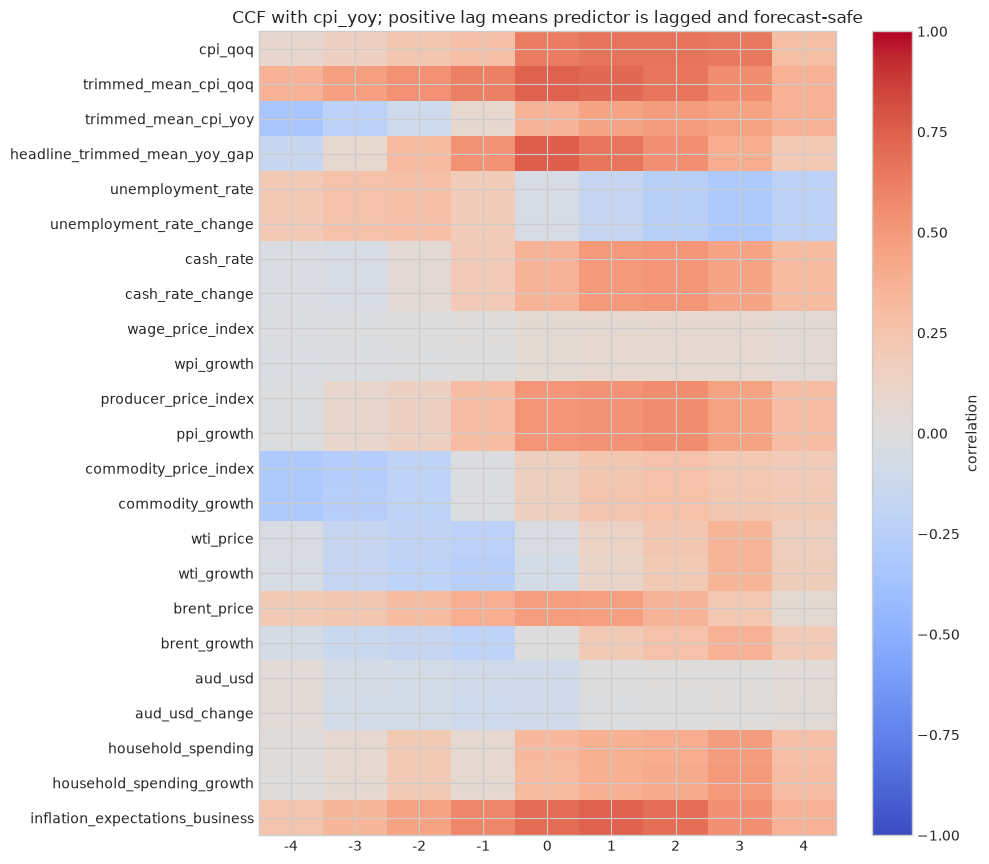

In [8]:
integration_lookup = dict(zip(stationarity['variable'], stationarity['integration_order']))

def stationary_series(column: str) -> pd.Series:
    series = clean_series(column)
    order = integration_lookup.get(column, 'unclear')
    if order == 'I(0)':
        result = series
    elif order == 'I(2)':
        result = series.diff().diff()
    else:
        log_diff = np.log(series.where(series > 0)).diff() if should_use_log_diff(column, series) else pd.Series(dtype='float64')
        result = log_diff if log_diff.notna().sum() >= 12 else series.diff()
    return result.replace([np.inf, -np.inf], np.nan).dropna()


def correlation_columns_for_target(target: str, include_cpi_diagnostics: bool) -> list[str]:
    cpi_diagnostics = [
        column for column in CPI_DIAGNOSTIC_BASE_COLS
        if include_cpi_diagnostics and column in df_model.columns and column != target
    ]
    return cpi_diagnostics + EXTERNAL_BASE_COLS


def compute_lead_lag_correlation(
    target: str,
    predictor_columns: list[str],
    max_lag: int = MAX_LAG,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    target_stationary_values = stationary_series(target).rename(target)
    ccf_rows = []
    for column in predictor_columns:
        x = stationary_series(column).rename(column)
        for lag in range(-max_lag, max_lag + 1):
            aligned = pd.concat([target_stationary_values, x.shift(lag)], axis=1).dropna()
            corr = aligned[target].corr(aligned[column]) if len(aligned) >= 12 else np.nan
            ccf_rows.append({
                'target': target,
                'variable': column,
                'lag_quarters': lag,
                'correlation': corr,
                'n_obs': len(aligned),
            })

    ccf_frame = pd.DataFrame(ccf_rows)
    positive_lag_ccf = ccf_frame.loc[ccf_frame['lag_quarters'] > 0].dropna(subset=['correlation']).copy()
    best_predictive = (
        positive_lag_ccf.assign(abs_correlation=lambda frame: frame['correlation'].abs())
        .sort_values(['variable', 'abs_correlation'], ascending=[True, False])
        .groupby('variable', as_index=False)
        .head(1)
        .sort_values('abs_correlation', ascending=False)
    )
    return ccf_frame, best_predictive, target_stationary_values


def display_lead_lag_correlation(
    target: str,
    predictor_columns: list[str],
    ccf_frame: pd.DataFrame,
    best_predictive: pd.DataFrame,
) -> None:
    display(best_predictive.round(4))

    heatmap_data = ccf_frame.pivot(index='variable', columns='lag_quarters', values='correlation').loc[predictor_columns]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.38 * len(predictor_columns))))
    image = ax.imshow(heatmap_data, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)
    ax.set_title(f'CCF with {target}; positive lag means predictor is lagged and forecast-safe')
    fig.colorbar(image, ax=ax, label='correlation')
    fig.tight_layout()
    plt.show()


CORRELATION_BASE_COLS = correlation_columns_for_target(TARGET, include_cpi_diagnostics=True)
ccf, best_predictive_ccf, target_stationary = compute_lead_lag_correlation(TARGET, CORRELATION_BASE_COLS)
display_lead_lag_correlation(TARGET, CORRELATION_BASE_COLS, ccf, best_predictive_ccf)

## 7. Granger Causality Screening

Granger tests are retained as predictive screens only. A significant result means past values of a predictor contain incremental predictive information for CPI inflation conditional on past CPI inflation. Granger causality is not structural or economic causality, especially for policy variables such as the RBA cash rate that also respond to inflation.

In [9]:
def compute_granger_screens(
    target: str,
    predictor_columns: list[str],
    target_stationary_values: pd.Series,
    best_predictive: pd.DataFrame,
    max_lag_limit: int = MAX_LAG,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int]]:
    best_lags = dict(zip(best_predictive['variable'], best_predictive['lag_quarters']))

    def granger_screen(variable: str) -> dict[str, object]:
        x = stationary_series(variable).rename(variable)
        data = pd.concat([target_stationary_values.rename(target), x], axis=1).dropna()
        max_lag = min(max_lag_limit, max(1, len(data) // 10))
        selected_lag = int(best_lags.get(variable, 1))
        selected_lag = min(max(selected_lag, 1), max_lag)
        base_record = {
            'target': target,
            'variable': variable,
            'selected_lag': selected_lag,
            'granger_p_value': np.nan,
            'min_granger_p_value': np.nan,
            'tested_lags': '',
            'n_obs': len(data),
            'note': 'insufficient stationary observations',
            'p_values_by_lag': {},
        }
        if len(data) < 24 or data[variable].nunique() < 3:
            return base_record
        try:
            result = grangercausalitytests(data[[target, variable]], maxlag=max_lag)
            p_values = {lag: float(result[lag][0]['ssr_ftest'][1]) for lag in range(1, max_lag + 1)}
            base_record.update({
                'granger_p_value': p_values.get(selected_lag, np.nan),
                'min_granger_p_value': min(p_values.values()) if p_values else np.nan,
                'tested_lags': ', '.join(f'{lag}:{p_value:.3f}' for lag, p_value in p_values.items()),
                'note': 'screening signal only; not structural causality',
                'p_values_by_lag': p_values,
            })
            return base_record
        except Exception as exc:
            base_record['note'] = f'granger failed: {type(exc).__name__}'
            return base_record

    records = [granger_screen(column) for column in predictor_columns]
    granger_frame = pd.DataFrame([{key: value for key, value in record.items() if key != 'p_values_by_lag'} for record in records])
    lag_results = pd.DataFrame([
        {
            'target': record['target'],
            'variable': record['variable'],
            'lag_quarters': lag,
            'granger_p_value': p_value,
            'n_obs': record['n_obs'],
        }
        for record in records
        for lag, p_value in record.get('p_values_by_lag', {}).items()
    ])
    return granger_frame, lag_results, {variable: int(lag) for variable, lag in best_lags.items()}


def display_granger_screens(granger_frame: pd.DataFrame, lag_results: pd.DataFrame) -> None:
    display(granger_frame.sort_values('granger_p_value', na_position='last').round(4))
    display(lag_results.sort_values(['variable', 'lag_quarters']).round(4))


granger, granger_lag_results, best_lag_lookup = compute_granger_screens(
    TARGET,
    CORRELATION_BASE_COLS,
    target_stationary,
    best_predictive_ccf,
)
display_granger_screens(granger, granger_lag_results)

,target,variable,selected_lag,granger_p_value,min_granger_p_value,tested_lags,n_obs,note
0,cpi_yoy,cpi_qoq,2,0.0000,0.0000,"1:0.000, 2:0.000, 3:0.000, 4:0.000",124,screening signal only; not structural causality
22,cpi_yoy,inflation_expectations_business,1,0.0000,0.0000,"1:0.000, 2:0.000, 3:0.000, 4:0.000",124,screening signal only; not structural causality
6,cpi_yoy,cash_rate,2,0.0001,0.0000,"1:0.000, 2:0.000, 3:0.001, 4:0.002",123,screening signal only; not structural causality
7,cpi_yoy,cash_rate_change,2,0.0001,0.0000,"1:0.000, 2:0.000, 3:0.001, 4:0.002",123,screening signal only; not structural causality
15,cpi_yoy,wti_growth,3,0.0001,0.0000,"1:0.002, 2:0.004, 3:0.000, 4:0.000",101,screening signal only; not structural causality
14,cpi_yoy,wti_price,3,0.0003,0.0000,"1:0.003, 2:0.006, 3:0.000, 4:0.000",101,screening signal only; not structural causality
17,cpi_yoy,brent_growth,3,0.0012,0.0002,"1:0.000, 2:0.007, 3:0.001, 4:0.000",73,screening signal only; not structural causality
21,cpi_yoy,household_spending_growth,3,0.0016,0.0016,"1:0.107, 2:0.103, 3:0.002, 4:0.013",53,screening signal only; not structural causality
20,cpi_yoy,household_spending,3,0.0037,0.0037,"1:0.132, 2:0.145, 3:0.004, 4:0.018",53,screening signal only; not structural causality
11,cpi_yoy,ppi_growth,2,0.0066,0.0066,"1:0.050, 2:0.007, 3:0.087, 4:0.142",109,screening signal only; not structural causality


,target,variable,lag_quarters,granger_p_value,n_obs
72,cpi_yoy,aud_usd,1,0.1987,63
73,cpi_yoy,aud_usd,2,0.4722,63
74,cpi_yoy,aud_usd,3,0.5591,63
75,cpi_yoy,aud_usd,4,0.8359,63
76,cpi_yoy,aud_usd_change,1,0.1972,63
...,...,...,...,...,...
63,cpi_yoy,wti_growth,4,0.0000,101
56,cpi_yoy,wti_price,1,0.0027,101
57,cpi_yoy,wti_price,2,0.0059,101
58,cpi_yoy,wti_price,3,0.0003,101


## 8. Multicollinearity And VIF

,target,candidate_feature,variable,candidate_lag,candidate_corr,candidate_abs_corr,candidate_granger_p_value,best_ccf_lag,best_ccf_corr,available_observations,coverage_pct
0,cpi_yoy,inflation_expectations_business_lag1,inflation_expectations_business,1,0.741,0.741,0.0000,1.0,0.741,124.0,1.000
1,cpi_yoy,ppi_growth_lag2,ppi_growth,2,0.556,0.556,0.0066,2.0,0.556,109.0,0.879
2,cpi_yoy,cash_rate_change_lag1,cash_rate_change,1,0.497,0.497,0.0000,2.0,0.511,123.0,0.992
3,cpi_yoy,unemployment_rate_change_lag1,unemployment_rate_change,1,-0.166,0.166,0.0088,3.0,-0.312,123.0,0.992
4,cpi_yoy,commodity_growth_lag1,commodity_growth,1,0.235,0.235,0.0228,2.0,0.266,123.0,0.992
5,cpi_yoy,wti_growth_lag1,wti_growth,1,0.106,0.106,0.0021,3.0,0.348,101.0,0.815
6,cpi_yoy,brent_growth_lag1,brent_growth,1,0.200,0.200,0.0003,3.0,0.365,73.0,0.589
7,cpi_yoy,wpi_growth_lag2,wpi_growth,2,0.061,0.061,0.8304,2.0,0.061,113.0,0.911
8,cpi_yoy,aud_usd_change_lag1,aud_usd_change,1,-0.008,0.008,0.1972,4.0,0.029,63.0,0.508
9,cpi_yoy,cash_rate_lag2,cash_rate,2,0.511,0.511,0.0001,2.0,0.511,124.0,1.000


,target,preferred_oil_feature_for_primary_vif,alternative_oil_feature,wti_growth_coverage_pct,brent_growth_coverage_pct,reason
0,cpi_yoy,wti_growth_lag1,brent_growth_lag1,0.815,0.589,WTI and Brent growth are alternative oil-price...


,target,primary_vif_feature
0,cpi_yoy,inflation_expectations_business_lag1
1,cpi_yoy,ppi_growth_lag2
2,cpi_yoy,cash_rate_change_lag1
3,cpi_yoy,unemployment_rate_change_lag1
4,cpi_yoy,commodity_growth_lag1
5,cpi_yoy,wti_growth_lag1
6,cpi_yoy,wpi_growth_lag2
7,cpi_yoy,aud_usd_change_lag1
8,cpi_yoy,cash_rate_lag2
9,cpi_yoy,covid_shock_rebound_lag1


,target,complete_rows_for_corr_vif,start_quarter,end_quarter
0,cpi_yoy,62,2010Q3,2025Q4


,inflation_expectations_business_lag1,ppi_growth_lag2,cash_rate_change_lag1,unemployment_rate_change_lag1,commodity_growth_lag1,wti_growth_lag1,wpi_growth_lag2,aud_usd_change_lag1,cash_rate_lag2,covid_shock_rebound_lag1,unemployment_rate_lag4
inflation_expectations_business_lag1,1.000,0.665,0.624,-0.306,0.130,0.077,0.265,-0.154,-0.080,-0.183,-0.415
ppi_growth_lag2,0.665,1.000,0.502,-0.153,0.074,-0.161,0.609,0.021,0.127,-0.099,-0.386
cash_rate_change_lag1,0.624,0.502,1.000,-0.195,0.082,-0.061,0.203,-0.061,-0.107,-0.142,-0.262
unemployment_rate_change_lag1,-0.306,-0.153,-0.195,1.000,-0.317,-0.448,0.051,0.061,0.234,0.719,-0.306
commodity_growth_lag1,0.130,0.074,0.082,-0.317,1.000,0.249,-0.073,-0.139,-0.273,-0.080,0.280
wti_growth_lag1,0.077,-0.161,-0.061,-0.448,0.249,1.000,-0.175,0.397,-0.157,-0.344,0.148
wpi_growth_lag2,0.265,0.609,0.203,0.051,-0.073,-0.175,1.000,0.038,0.493,-0.094,-0.404
aud_usd_change_lag1,-0.154,0.021,-0.061,0.061,-0.139,0.397,0.038,1.000,0.091,0.135,-0.039
cash_rate_lag2,-0.080,0.127,-0.107,0.234,-0.273,-0.157,0.493,0.091,1.000,-0.160,-0.513
covid_shock_rebound_lag1,-0.183,-0.099,-0.142,0.719,-0.080,-0.344,-0.094,0.135,-0.160,1.000,0.005


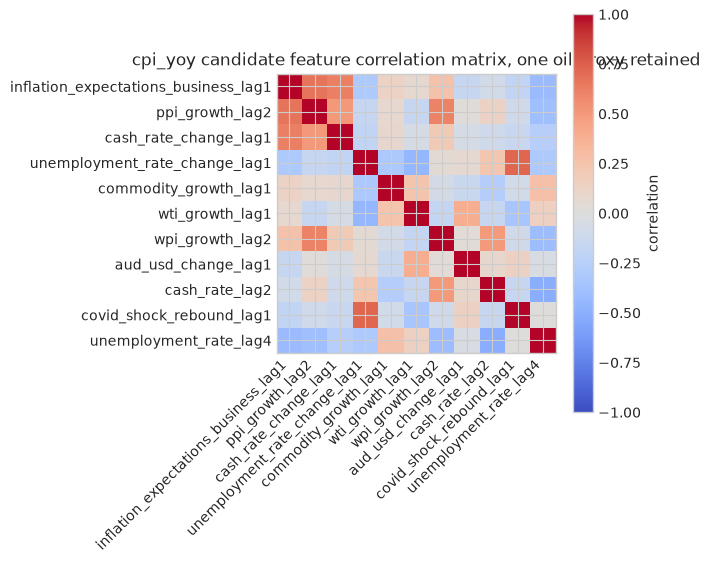

,candidate_feature,vif
6,wpi_growth_lag2,12.736
0,inflation_expectations_business_lag1,9.585
1,ppi_growth_lag2,7.771
10,unemployment_rate_lag4,7.502
8,cash_rate_lag2,6.782
3,unemployment_rate_change_lag1,3.598
9,covid_shock_rebound_lag1,3.329
5,wti_growth_lag1,2.309
7,aud_usd_change_lag1,1.848
2,cash_rate_change_lag1,1.794


CPI-family lag VIF diagnostic for autoregressive headline terms and trimmed-mean CPI lag.

,candidate_feature,observations,vif
2,trimmed_mean_cpi_yoy_lag1,120,3.427
0,cpi_yoy_lag1,120,2.490
1,cpi_yoy_lag4,120,1.854


In [10]:
def lag_base_name(feature: str) -> str:
    return re.sub(r'_lag\d+$', '', feature)


def feature_lag(feature: str | None) -> int | None:
    if feature is None:
        return None
    match = re.search(r'_lag(\d+)$', feature)
    return int(match.group(1)) if match else None


availability_assumptions = pd.read_csv(AVAILABILITY_PATH)
availability_assumptions['assumed_min_safe_lag_quarters'] = availability_assumptions['assumed_min_safe_lag_quarters'].astype(int)

# Notebook-only rate-change features inherit the release-lag assumption of their
# source rate level; no exact release dates are fabricated here.
for source_col in RATE_CHANGE_LAG_MAP:
    change_col = f'{source_col}_change'
    if change_col in EXTERNAL_BASE_COLS and change_col not in set(availability_assumptions['variable']) and source_col in set(availability_assumptions['variable']):
        source_row = availability_assumptions.loc[availability_assumptions['variable'] == source_col].iloc[0].copy()
        source_row['variable'] = change_col
        source_row['source_family'] = f"derived {source_row['source_family']} change"
        source_row['assumption_note'] = f"Inherits {source_col} release-lag assumption; transformed as percentage-point change."
        availability_assumptions = pd.concat([availability_assumptions, source_row.to_frame().T], ignore_index=True)

missing_availability_metadata = sorted(set(EXTERNAL_BASE_COLS) - set(availability_assumptions['variable']))
if missing_availability_metadata:
    raise ValueError(f'Missing availability metadata for: {missing_availability_metadata}')

availability_assumptions['assumed_min_safe_lag_quarters'] = availability_assumptions['assumed_min_safe_lag_quarters'].astype(int)
availability_lookup = availability_assumptions.set_index('variable')['assumed_min_safe_lag_quarters'].to_dict()
lagged_feature_bases = {lag_base_name(feature) for feature in EXTERNAL_LAGGED_FEATURES}

def min_safe_lag_for_base(base: str) -> int:
    return int(availability_lookup.get(base, 0))


def build_target_candidate_artifacts(
    target: str,
    best_predictive: pd.DataFrame,
    ccf_frame: pd.DataFrame,
    granger_lags: pd.DataFrame,
    show_diagnostics: bool = True,
) -> dict[str, object]:
    target_best_lag_lookup = dict(zip(best_predictive['variable'], best_predictive['lag_quarters']))

    def target_ccf_corr_at_lag(variable: str, lag: int | None) -> float:
        if lag is None:
            return np.nan
        match = ccf_frame.loc[(ccf_frame['variable'] == variable) & (ccf_frame['lag_quarters'] == lag), 'correlation']
        return float(match.iloc[0]) if not match.empty else np.nan

    def target_granger_p_at_lag(variable: str, lag: int | None) -> float:
        if lag is None or granger_lags.empty:
            return np.nan
        match = granger_lags.loc[(granger_lags['variable'] == variable) & (granger_lags['lag_quarters'] == lag), 'granger_p_value']
        return float(match.iloc[0]) if not match.empty else np.nan

    def choose_safe_lagged_feature(base: str, matching_features: list[str]) -> str | None:
        min_safe_lag = min_safe_lag_for_base(base)
        safe_features = [feature for feature in matching_features if (feature_lag(feature) or -1) >= min_safe_lag]
        if not safe_features:
            return None
        preferred_lag = max(int(target_best_lag_lookup.get(base, feature_lag(safe_features[0]) or min_safe_lag)), min_safe_lag)
        exact = [feature for feature in safe_features if feature_lag(feature) == preferred_lag]
        if exact:
            return exact[0]
        at_or_above_preferred = [feature for feature in safe_features if (feature_lag(feature) or 99) >= preferred_lag]
        return sorted(at_or_above_preferred or safe_features, key=lambda feature: feature_lag(feature) or 99)[0]

    all_lagged_bases = sorted({lag_base_name(feature) for feature in EXTERNAL_LAGGED_FEATURES})
    base_screen_order = [base for base in EXOGENOUS_CANDIDATE_BASE_PRIORITY if base in all_lagged_bases]
    base_screen_order += [base for base in all_lagged_bases if base not in base_screen_order and base not in cpi_family_exclusion_cols]

    feature_choices = []
    for base in base_screen_order:
        matching_features = [feature for feature in EXTERNAL_LAGGED_FEATURES if lag_base_name(feature) == base]
        chosen = choose_safe_lagged_feature(base, matching_features)
        if chosen is not None and df[chosen].notna().mean() >= 0.50:
            feature_choices.append(chosen)

    candidate_features = list(dict.fromkeys(feature_choices))

    oil_pair_decision = pd.DataFrame()
    vif_features = candidate_features.copy()
    if 'wti_growth_lag1' in candidate_features and 'brent_growth_lag1' in candidate_features:
        wti_coverage = float(coverage.set_index('variable').loc['wti_growth', 'coverage_pct'])
        brent_coverage = float(coverage.set_index('variable').loc['brent_growth', 'coverage_pct'])
        preferred_oil_feature = 'wti_growth_lag1' if wti_coverage >= brent_coverage else 'brent_growth_lag1'
        dropped_oil_feature = 'brent_growth_lag1' if preferred_oil_feature == 'wti_growth_lag1' else 'wti_growth_lag1'
        vif_features = [feature for feature in vif_features if feature != dropped_oil_feature]
        oil_pair_decision = pd.DataFrame([{
            'target': target,
            'preferred_oil_feature_for_primary_vif': preferred_oil_feature,
            'alternative_oil_feature': dropped_oil_feature,
            'wti_growth_coverage_pct': wti_coverage,
            'brent_growth_coverage_pct': brent_coverage,
            'reason': 'WTI and Brent growth are alternative oil-price proxies; include at most one in an Elastic Net specification.',
        }])

    coverage_by_variable = coverage.set_index('variable')
    candidate_feature_diagnostics = pd.DataFrame([
        {
            'target': target,
            'candidate_feature': feature,
            'variable': lag_base_name(feature),
            'candidate_lag': feature_lag(feature),
            'candidate_corr': target_ccf_corr_at_lag(lag_base_name(feature), feature_lag(feature)),
            'candidate_abs_corr': abs(target_ccf_corr_at_lag(lag_base_name(feature), feature_lag(feature))),
            'candidate_granger_p_value': target_granger_p_at_lag(lag_base_name(feature), feature_lag(feature)),
            'best_ccf_lag': int(target_best_lag_lookup.get(lag_base_name(feature), np.nan)) if lag_base_name(feature) in target_best_lag_lookup else np.nan,
            'best_ccf_corr': target_ccf_corr_at_lag(lag_base_name(feature), int(target_best_lag_lookup.get(lag_base_name(feature), 1))) if lag_base_name(feature) in target_best_lag_lookup else np.nan,
            'available_observations': int(coverage_by_variable.loc[lag_base_name(feature), 'available_observations']) if lag_base_name(feature) in coverage_by_variable.index else np.nan,
            'coverage_pct': float(coverage_by_variable.loc[lag_base_name(feature), 'coverage_pct']) if lag_base_name(feature) in coverage_by_variable.index else np.nan,
        }
        for feature in candidate_features
    ])

    candidate_matrix = df[vif_features].apply(pd.to_numeric, errors='coerce').dropna()
    candidate_sample_summary = {'target': target, 'complete_rows_for_corr_vif': int(len(candidate_matrix))}
    if not candidate_matrix.empty:
        candidate_quarters = df.loc[candidate_matrix.index, 'quarter_period']
        candidate_sample_summary.update({'start_quarter': str(candidate_quarters.iloc[0]), 'end_quarter': str(candidate_quarters.iloc[-1])})
    candidate_sample_summary = pd.DataFrame([candidate_sample_summary])

    corr_matrix = pd.DataFrame()
    if len(vif_features) >= 2 and len(candidate_matrix) >= 24:
        corr_matrix = candidate_matrix.corr()
        vif_rows = []
        vif_input = candidate_matrix.astype(float)
        for index, feature in enumerate(vif_input.columns):
            vif_rows.append({'candidate_feature': feature, 'vif': variance_inflation_factor(vif_input.values, index)})
        vif = pd.DataFrame(vif_rows).sort_values('vif', ascending=False)
    else:
        vif = pd.DataFrame({'candidate_feature': vif_features, 'vif': np.nan, 'note': 'not enough candidate features or complete rows for VIF'})

    if show_diagnostics:
        display(candidate_feature_diagnostics.round({'candidate_corr': 3, 'candidate_abs_corr': 3, 'candidate_granger_p_value': 4, 'best_ccf_corr': 3, 'coverage_pct': 3}))
        if not oil_pair_decision.empty:
            display(oil_pair_decision.round(3))
        display(pd.DataFrame({'target': target, 'primary_vif_feature': vif_features}))
        display(candidate_sample_summary)
        if not corr_matrix.empty:
            display(corr_matrix.round(3))
            fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(vif_features)), max(5, 0.55 * len(vif_features))))
            image = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
            ax.set_xticks(range(len(corr_matrix.columns)))
            ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
            ax.set_yticks(range(len(corr_matrix.index)))
            ax.set_yticklabels(corr_matrix.index)
            ax.set_title(f'{target} candidate feature correlation matrix, one oil proxy retained')
            fig.colorbar(image, ax=ax, label='correlation')
            fig.tight_layout()
            plt.show()
        display(vif.round(3))

    return {
        'target': target,
        'candidate_features': candidate_features,
        'vif_features': vif_features,
        'oil_pair_decision': oil_pair_decision,
        'candidate_feature_diagnostics': candidate_feature_diagnostics,
        'candidate_matrix': candidate_matrix,
        'candidate_sample_summary': candidate_sample_summary,
        'corr_matrix': corr_matrix,
        'vif': vif,
        'best_lag_lookup': target_best_lag_lookup,
        'ccf_corr_at_lag': target_ccf_corr_at_lag,
        'granger_p_at_lag': target_granger_p_at_lag,
        'choose_safe_lagged_feature': choose_safe_lagged_feature,
    }


EXOGENOUS_CANDIDATE_BASE_PRIORITY = [
    'inflation_expectations_business',
    'ppi_growth',
    'cash_rate_change',
    'unemployment_rate_change',
    'commodity_growth',
    'wti_growth',
    'brent_growth',
    'wpi_growth',
    'aud_usd_change',
    'household_spending_growth',
]

headline_candidate_artifacts = build_target_candidate_artifacts(
    TARGET,
    best_predictive_ccf,
    ccf,
    granger_lag_results,
    show_diagnostics=True,
)
candidate_features = headline_candidate_artifacts['candidate_features']
vif_features = headline_candidate_artifacts['vif_features']
oil_pair_decision = headline_candidate_artifacts['oil_pair_decision']
candidate_feature_diagnostics = headline_candidate_artifacts['candidate_feature_diagnostics']
candidate_matrix = headline_candidate_artifacts['candidate_matrix']
vif = headline_candidate_artifacts['vif']
ccf_corr_at_lag = headline_candidate_artifacts['ccf_corr_at_lag']
granger_p_at_lag = headline_candidate_artifacts['granger_p_at_lag']

cpi_family_vif_features = [feature for feature in ['cpi_yoy_lag1', 'cpi_yoy_lag4', 'trimmed_mean_cpi_yoy_lag1'] if feature in df_model.columns]
cpi_family_vif_input = df[cpi_family_vif_features].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
if len(cpi_family_vif_features) >= 2 and len(cpi_family_vif_input) >= 24:
    cpi_family_standardized = (cpi_family_vif_input - cpi_family_vif_input.mean()) / cpi_family_vif_input.std(ddof=0)
    cpi_family_standardized = cpi_family_standardized.loc[:, cpi_family_standardized.nunique(dropna=True) > 1]
    cpi_family_vif_matrix = add_constant(cpi_family_standardized, has_constant='add')
    cpi_family_vif_rows = []
    for index, feature in enumerate(cpi_family_standardized.columns):
        cpi_family_vif_rows.append({
            'candidate_feature': feature,
            'observations': int(len(cpi_family_standardized)),
            'vif': variance_inflation_factor(cpi_family_vif_matrix.to_numpy(), index + 1),
        })
    cpi_family_vif = pd.DataFrame(cpi_family_vif_rows).sort_values('vif', ascending=False)
else:
    cpi_family_vif = pd.DataFrame({'candidate_feature': cpi_family_vif_features, 'observations': len(cpi_family_vif_input), 'vif': np.nan})

display(Markdown('CPI-family lag VIF diagnostic for autoregressive headline terms and trimmed-mean CPI lag.'))
display(cpi_family_vif.round(3))

## 9. Leakage And Forecast-Origin Availability Assumptions

The curated schema does not contain publication dates. The metadata file below is an explicit assumption set for a one-quarter-ahead modelling workflow. It distinguishes the observation quarter, the release/publication lag, and the forecast origin, but it does not contain true historical release vintages. The project currently uses revised historical ABS/RBA/market data, so the safe-lag check is a transparent leakage-control assumption rather than a real-time data audit.

In [11]:
feature_availability = []
for feature in EXTERNAL_LAGGED_FEATURES:
    base = lag_base_name(feature)
    lag = feature_lag(feature)
    assumption = availability_assumptions.loc[availability_assumptions['variable'] == base]
    min_safe_lag = int(assumption['assumed_min_safe_lag_quarters'].iloc[0]) if not assumption.empty else np.nan
    feature_availability.append({
        'candidate_feature': feature,
        'variable': base,
        'feature_lag_quarters': lag,
        'assumed_min_safe_lag_quarters': min_safe_lag,
        'forecast_origin_safe_under_assumption': bool(pd.notna(min_safe_lag) and lag >= min_safe_lag),
    })

feature_availability = pd.DataFrame(feature_availability)
display(availability_assumptions)
display(feature_availability)

,variable,source_family,assumed_min_safe_lag_quarters,assumption_note
0,unemployment_rate,ABS labour force,1,Monthly labour data can be revised and should ...
1,cash_rate,RBA policy rate,0,Policy rate is public when set; lagged feature...
2,wage_price_index,ABS WPI,1,Quarterly WPI is typically released after CPI ...
3,wpi_growth,derived ABS WPI growth,1,Inherits WPI release lag.
4,producer_price_index,ABS PPI,1,Conservative quarterly release-lag assumption.
5,ppi_growth,derived ABS PPI growth,1,Inherits PPI release lag.
6,commodity_price_index,RBA commodity index,1,Monthly or quarterly aggregation should avoid ...
7,commodity_growth,derived RBA commodity growth,1,Inherits commodity index aggregation lag.
8,wti_price,market price,0,Market data is observable daily; lagged featur...
9,wti_growth,derived WTI growth,0,Inherits market-data availability.


,candidate_feature,variable,feature_lag_quarters,assumed_min_safe_lag_quarters,forecast_origin_safe_under_assumption
0,cash_rate_lag1,cash_rate,1,0.0,True
1,cash_rate_lag2,cash_rate,2,0.0,True
2,cash_rate_lag4,cash_rate,4,0.0,True
3,unemployment_rate_lag1,unemployment_rate,1,1.0,True
4,unemployment_rate_lag2,unemployment_rate,2,1.0,True
5,unemployment_rate_lag4,unemployment_rate,4,1.0,True
6,wpi_growth_lag1,wpi_growth,1,1.0,True
7,wpi_growth_lag2,wpi_growth,2,1.0,True
8,ppi_growth_lag1,ppi_growth,1,1.0,True
9,ppi_growth_lag2,ppi_growth,2,1.0,True


## 10. Candidate Exogenous Feature Screening For Elastic Net

This table is an Elastic Net candidate pool, not final feature selection. EDA diagnostics such as CCF, Granger tests, VIF, missingness, and stability checks identify plausible regressors. The final Elastic Net feature set must be selected later with rolling-origin or walk-forward forecasting performance. In short: EDA screens candidate regressors; out-of-sample rolling-origin forecasting selects the final Elastic Net feature set.

In [12]:
coverage_lookup = coverage.set_index('variable')
stationarity_lookup = stationarity.set_index('variable')


def classify_candidate(row: pd.Series) -> tuple[str, str]:
    blockers = []
    warnings = []
    signals = []

    if not row.get('has_lag_feature', False):
        blockers.append('no lagged feature engineered in this notebook/src/features.py')
    elif pd.isna(row.get('feature_lag_quarters')):
        blockers.append('no candidate lag selected after availability/sample screen')
    elif row.get('forecast_origin_safe_under_assumption') is False:
        blockers.append('unsafe under assumed publication-lag metadata')

    if pd.notna(row.get('vif')) and row.get('vif') > VIF_THRESHOLD:
        warnings.append('high VIF in primary candidate matrix')
    if row.get('late_start_reduces_estimation_sample', False):
        warnings.append('starts later than full sample; reduces estimation window')
    if row.get('substantial_missingness_warning', False):
        warnings.append('substantial missingness warning')
    if row.get('candidate_feature') in row.get('oil_alternative_features', set()):
        warnings.append('alternative oil proxy; use at most one of WTI/Brent in an Elastic Net specification')

    if pd.notna(row.get('candidate_abs_corr')) and row.get('candidate_abs_corr') >= SIGNAL_CORR_THRESHOLD:
        signals.append('candidate-lag CCF signal')
    if pd.notna(row.get('candidate_granger_p_value')) and row.get('candidate_granger_p_value') <= SIGNAL_P_THRESHOLD:
        signals.append('candidate-lag Granger screening signal')

    if blockers:
        return 'exclude', '; '.join(blockers + warnings) if warnings else '; '.join(blockers)
    if not signals:
        return 'optional', '; '.join(warnings + ['weak candidate-lag CCF/Granger screening signal']) if warnings else 'weak candidate-lag CCF/Granger screening signal'
    strong_signal = (
        pd.notna(row.get('candidate_abs_corr')) and row.get('candidate_abs_corr') >= 0.40
    ) or (
        pd.notna(row.get('candidate_granger_p_value')) and row.get('candidate_granger_p_value') <= 0.05
    )
    if strong_signal and not row.get('substantial_missingness_warning', False) and not (pd.notna(row.get('vif')) and row.get('vif') > VIF_THRESHOLD):
        return 'strong candidate', '; '.join(warnings + signals) if warnings else '; '.join(signals)
    if warnings:
        return 'optional/shorter-sample candidate', '; '.join(warnings + signals)
    return 'candidate', '; '.join(signals)


def build_target_shortlist(
    target: str,
    candidate_artifacts: dict[str, object],
    best_predictive: pd.DataFrame,
    granger_frame: pd.DataFrame,
    message_prefix: str,
    show_result: bool = True,
) -> dict[str, object]:
    candidate_diag = candidate_artifacts['candidate_feature_diagnostics']
    candidate_diag_lookup = candidate_diag.set_index('candidate_feature') if not candidate_diag.empty else pd.DataFrame()
    chosen_feature_by_base = {lag_base_name(feature): feature for feature in candidate_artifacts['candidate_features']}
    vif_frame = candidate_artifacts['vif']
    vif_lookup = vif_frame.set_index('candidate_feature')['vif'].to_dict() if not vif_frame.empty else {}
    ccf_lookup = best_predictive.set_index('variable')
    granger_lookup_frame = granger_frame.set_index('variable')
    oil_alternative_features = set(candidate_artifacts['oil_pair_decision']['alternative_oil_feature']) if not candidate_artifacts['oil_pair_decision'].empty else set()

    shortlist_rows = []
    for variable in EXTERNAL_BASE_COLS:
        chosen_feature = chosen_feature_by_base.get(variable)
        availability_row = feature_availability.loc[feature_availability['candidate_feature'] == chosen_feature].iloc[0].to_dict() if chosen_feature in set(feature_availability['candidate_feature']) else {}
        candidate_row = candidate_diag_lookup.loc[chosen_feature].to_dict() if chosen_feature in candidate_diag_lookup.index else {}
        row = {
            'target': target,
            'variable': variable,
            'candidate_feature': chosen_feature,
            'has_lag_feature': variable in lagged_feature_bases,
            'integration_order': stationarity_lookup.loc[variable, 'integration_order'] if variable in stationarity_lookup.index else None,
            'best_ccf_lag': int(ccf_lookup.loc[variable, 'lag_quarters']) if variable in ccf_lookup.index else np.nan,
            'best_ccf_corr': ccf_lookup.loc[variable, 'correlation'] if variable in ccf_lookup.index else np.nan,
            'candidate_lag': candidate_row.get('candidate_lag', np.nan),
            'candidate_corr': candidate_row.get('candidate_corr', np.nan),
            'candidate_abs_corr': candidate_row.get('candidate_abs_corr', np.nan),
            'candidate_granger_p_value': candidate_row.get('candidate_granger_p_value', np.nan),
            'min_granger_p_value': granger_lookup_frame.loc[variable, 'min_granger_p_value'] if variable in granger_lookup_frame.index else np.nan,
            'vif': vif_lookup.get(chosen_feature, np.nan),
            'assumed_min_safe_lag_quarters': availability_assumptions.set_index('variable').loc[variable, 'assumed_min_safe_lag_quarters'] if variable in set(availability_assumptions['variable']) else np.nan,
            'feature_lag_quarters': availability_row.get('feature_lag_quarters', np.nan),
            'forecast_origin_safe_under_assumption': availability_row.get('forecast_origin_safe_under_assumption', False),
            'available_observations': coverage_lookup.loc[variable, 'available_observations'] if variable in coverage_lookup.index else np.nan,
            'coverage_pct': coverage_lookup.loc[variable, 'coverage_pct'] if variable in coverage_lookup.index else np.nan,
            'missing_pct': coverage_lookup.loc[variable, 'missing_pct'] if variable in coverage_lookup.index else np.nan,
            'first_non_null': coverage_lookup.loc[variable, 'first_non_null'] if variable in coverage_lookup.index else None,
            'last_non_null': coverage_lookup.loc[variable, 'last_non_null'] if variable in coverage_lookup.index else None,
            'coverage_class': coverage_lookup.loc[variable, 'coverage_class'] if variable in coverage_lookup.index else None,
            'late_start_reduces_estimation_sample': bool(coverage_lookup.loc[variable, 'late_start_reduces_estimation_sample']) if variable in coverage_lookup.index else True,
            'substantial_missingness_warning': bool(coverage_lookup.loc[variable, 'substantial_missingness_warning']) if variable in coverage_lookup.index else True,
            'oil_alternative_features': oil_alternative_features,
        }
        row['screening_status'], row['reason'] = classify_candidate(pd.Series(row))
        row.pop('oil_alternative_features', None)
        shortlist_rows.append(row)

    shortlist = pd.DataFrame(shortlist_rows).sort_values(['screening_status', 'candidate_granger_p_value', 'candidate_abs_corr'], ascending=[True, True, False])
    strong_or_candidate_features = shortlist.loc[shortlist['screening_status'].isin(['strong candidate', 'candidate', 'optional/shorter-sample candidate']), 'candidate_feature'].dropna().tolist()
    if strong_or_candidate_features:
        message = message_prefix + ': ' + ', '.join(strong_or_candidate_features)
    else:
        message = f'No external variables passed the candidate screening checks for {target}. Revisit feature engineering before Elastic Net modelling.'

    if show_result:
        display(shortlist.round({'best_ccf_corr': 3, 'candidate_corr': 3, 'candidate_abs_corr': 3, 'candidate_granger_p_value': 4, 'min_granger_p_value': 4, 'vif': 2, 'missing_pct': 3, 'coverage_pct': 3}))
        display(Markdown(message + '\n\nThese are not final feature-selection results. The modelling stage should compare a small set of nested Elastic Net feature specifications with walk-forward RMSE/MAE against seasonal-naive and SARIMA baselines, not exhaustive subset search on this small sample.'))

    return {
        'shortlist': shortlist,
        'chosen_feature_by_base': chosen_feature_by_base,
        'message': message,
        'strong_or_candidate_features': strong_or_candidate_features,
    }


headline_shortlist_artifacts = build_target_shortlist(
    TARGET,
    headline_candidate_artifacts,
    best_predictive_ccf,
    granger,
    'Elastic Net candidate pool from headline CPI EDA screening',
    show_result=True,
)
shortlist = headline_shortlist_artifacts['shortlist']
chosen_feature_by_base = headline_shortlist_artifacts['chosen_feature_by_base']

cpi_family_vif_lookup = cpi_family_vif.set_index('candidate_feature')['vif'].to_dict() if not cpi_family_vif.empty else {}
cpi_family_screening_rows = []
headline_ccf_lookup = best_predictive_ccf.set_index('variable')
headline_granger_lookup_frame = granger.set_index('variable')
for variable in [column for column in CPI_DIAGNOSTIC_BASE_COLS if column in df_model.columns]:
    lag_feature = 'trimmed_mean_cpi_yoy_lag1' if variable == 'trimmed_mean_cpi_yoy' else None
    diagnostic_lag = feature_lag(lag_feature) if lag_feature else int(headline_ccf_lookup.loc[variable, 'lag_quarters']) if variable in headline_ccf_lookup.index else np.nan
    row = {
        'variable': variable,
        'lag_feature_reviewed': lag_feature,
        'integration_order': stationarity_lookup.loc[variable, 'integration_order'] if variable in stationarity_lookup.index else None,
        'best_ccf_lag': int(headline_ccf_lookup.loc[variable, 'lag_quarters']) if variable in headline_ccf_lookup.index else np.nan,
        'best_ccf_corr': headline_ccf_lookup.loc[variable, 'correlation'] if variable in headline_ccf_lookup.index else np.nan,
        'diagnostic_lag': diagnostic_lag,
        'diagnostic_lag_corr': ccf_corr_at_lag(variable, diagnostic_lag) if pd.notna(diagnostic_lag) else np.nan,
        'diagnostic_lag_granger_p_value': granger_p_at_lag(variable, diagnostic_lag) if pd.notna(diagnostic_lag) else np.nan,
        'min_granger_p_value': headline_granger_lookup_frame.loc[variable, 'min_granger_p_value'] if variable in headline_granger_lookup_frame.index else np.nan,
        'vif_if_lag_feature_reviewed': cpi_family_vif_lookup.get(lag_feature, np.nan),
        'screening_note': 'CPI-family diagnostic; keep out of generic external Elastic Net feature pool pending out-of-sample tests.',
    }
    cpi_family_screening_rows.append(row)

cpi_family_screening_diagnostics = pd.DataFrame(cpi_family_screening_rows)
display(Markdown('CPI-family diagnostics below are reviewed separately from ordinary exogenous macro indicators because they are alternative CPI measures or headline-minus-underlying inflation transforms.'))
display(cpi_family_screening_diagnostics.round({'best_ccf_corr': 3, 'diagnostic_lag_corr': 3, 'diagnostic_lag_granger_p_value': 4, 'min_granger_p_value': 4, 'vif_if_lag_feature_reviewed': 2}))

,target,variable,candidate_feature,has_lag_feature,integration_order,best_ccf_lag,best_ccf_corr,candidate_lag,candidate_corr,candidate_abs_corr,candidate_granger_p_value,min_granger_p_value,vif,assumed_min_safe_lag_quarters,feature_lag_quarters,forecast_origin_safe_under_assumption,available_observations,coverage_pct,missing_pct,first_non_null,last_non_null,coverage_class,late_start_reduces_estimation_sample,substantial_missingness_warning,screening_status,reason
0,cpi_yoy,unemployment_rate,unemployment_rate_lag4,True,I(1),3,-0.312,4.0,-0.226,0.226,0.1817,0.0088,7.50,1,4.0,True,124,1.000,0.000,1995Q1,2025Q4,core_long_sample_candidate,False,False,candidate,candidate-lag CCF signal
4,cpi_yoy,wage_price_index,None,False,I(2),2,0.065,NaN,NaN,NaN,NaN,0.7792,NaN,1,NaN,False,114,0.919,0.081,1997Q3,2025Q4,shorter_sample_candidate,True,False,exclude,no lagged feature engineered in this notebook/...
6,cpi_yoy,producer_price_index,None,False,I(1),2,0.555,NaN,NaN,NaN,NaN,0.0068,NaN,1,NaN,False,110,0.887,0.113,1998Q3,2025Q4,shorter_sample_candidate,True,False,exclude,no lagged feature engineered in this notebook/...
8,cpi_yoy,commodity_price_index,None,False,I(1),2,0.263,NaN,NaN,NaN,NaN,0.0230,NaN,1,NaN,False,124,1.000,0.000,1995Q1,2025Q4,core_long_sample_candidate,False,False,exclude,no lagged feature engineered in this notebook/...
10,cpi_yoy,wti_price,None,False,I(1),3,0.348,NaN,NaN,NaN,NaN,0.0000,NaN,0,NaN,False,102,0.823,0.177,2000Q3,2025Q4,shorter_sample_candidate,True,False,exclude,no lagged feature engineered in this notebook/...
12,cpi_yoy,brent_price,None,False,I(0),1,0.467,NaN,NaN,NaN,NaN,0.0084,NaN,0,NaN,False,74,0.597,0.403,2007Q3,2025Q4,limited_sample_candidate,True,True,exclude,no lagged feature engineered in this notebook/...
14,cpi_yoy,aud_usd,None,False,I(1),4,0.032,NaN,NaN,NaN,NaN,0.1987,NaN,0,NaN,False,64,0.516,0.484,2010Q1,2025Q4,limited_sample_candidate,True,True,exclude,no lagged feature engineered in this notebook/...
16,cpi_yoy,household_spending,None,False,I(1),3,0.482,NaN,NaN,NaN,NaN,0.0037,NaN,1,NaN,False,54,0.435,0.565,2012Q3,2025Q4,exclude_low_coverage,True,True,exclude,no lagged feature engineered in this notebook/...
17,cpi_yoy,household_spending_growth,None,True,I(0),3,0.494,NaN,NaN,NaN,NaN,0.0016,NaN,1,NaN,False,53,0.427,0.573,2012Q4,2025Q4,exclude_low_coverage,True,True,exclude,no candidate lag selected after availability/s...
15,cpi_yoy,aud_usd_change,aud_usd_change_lag1,True,I(0),4,0.029,1.0,-0.008,0.008,0.1972,0.1972,1.85,0,1.0,True,63,0.508,0.492,2010Q2,2025Q4,limited_sample_candidate,True,True,optional,starts later than full sample; reduces estimat...


Elastic Net candidate pool from headline CPI EDA screening: unemployment_rate_lag4, brent_growth_lag1, cash_rate_change_lag1, inflation_expectations_business_lag1, cash_rate_lag2, wti_growth_lag1, ppi_growth_lag2, unemployment_rate_change_lag1, commodity_growth_lag1

These are not final feature-selection results. The modelling stage should compare a small set of nested Elastic Net feature specifications with walk-forward RMSE/MAE against seasonal-naive and SARIMA baselines, not exhaustive subset search on this small sample.

CPI-family diagnostics below are reviewed separately from ordinary exogenous macro indicators because they are alternative CPI measures or headline-minus-underlying inflation transforms.

,variable,lag_feature_reviewed,integration_order,best_ccf_lag,best_ccf_corr,diagnostic_lag,diagnostic_lag_corr,diagnostic_lag_granger_p_value,min_granger_p_value,vif_if_lag_feature_reviewed,screening_note
0,cpi_qoq,None,I(0),2,0.670,2,0.670,0.0000,0.0000,NaN,CPI-family diagnostic; keep out of generic ext...
1,trimmed_mean_cpi_qoq,None,I(0),1,0.717,1,0.717,0.0075,0.0008,NaN,CPI-family diagnostic; keep out of generic ext...
2,trimmed_mean_cpi_yoy,trimmed_mean_cpi_yoy_lag1,I(1),2,0.477,1,0.440,0.0016,0.0016,3.43,CPI-family diagnostic; keep out of generic ext...
3,headline_trimmed_mean_yoy_gap,None,I(0),1,0.659,1,0.659,0.8141,0.0359,NaN,CPI-family diagnostic; keep out of generic ext...


## 10b. Candidate Exogenous Feature Screening For Trimmed-Mean Elastic Net

This repeats the same external-macro screening workflow with `trimmed_mean_cpi_yoy` as the target. It excludes CPI-family diagnostic columns as predictors so the trimmed-mean model receives an independent candidate exogenous pool rather than a second headline-CPI comparison.

,target,variable,lag_quarters,correlation,n_obs,abs_correlation
158,trimmed_mean_cpi_yoy,household_spending_growth,1,0.4000,52,0.4000
149,trimmed_mean_cpi_yoy,household_spending,1,0.3854,52,0.3854
77,trimmed_mean_cpi_yoy,commodity_price_index,1,0.3287,122,0.3287
86,trimmed_mean_cpi_yoy,commodity_growth,1,0.3226,122,0.3226
124,trimmed_mean_cpi_yoy,brent_growth,3,0.3208,70,0.3208
116,trimmed_mean_cpi_yoy,brent_price,4,-0.3065,70,0.3065
106,trimmed_mean_cpi_yoy,wti_growth,3,0.3039,98,0.3039
96,trimmed_mean_cpi_yoy,wti_price,2,0.3032,99,0.3032
16,trimmed_mean_cpi_yoy,unemployment_rate_change,3,-0.2967,120,0.2967
7,trimmed_mean_cpi_yoy,unemployment_rate,3,-0.2967,120,0.2967


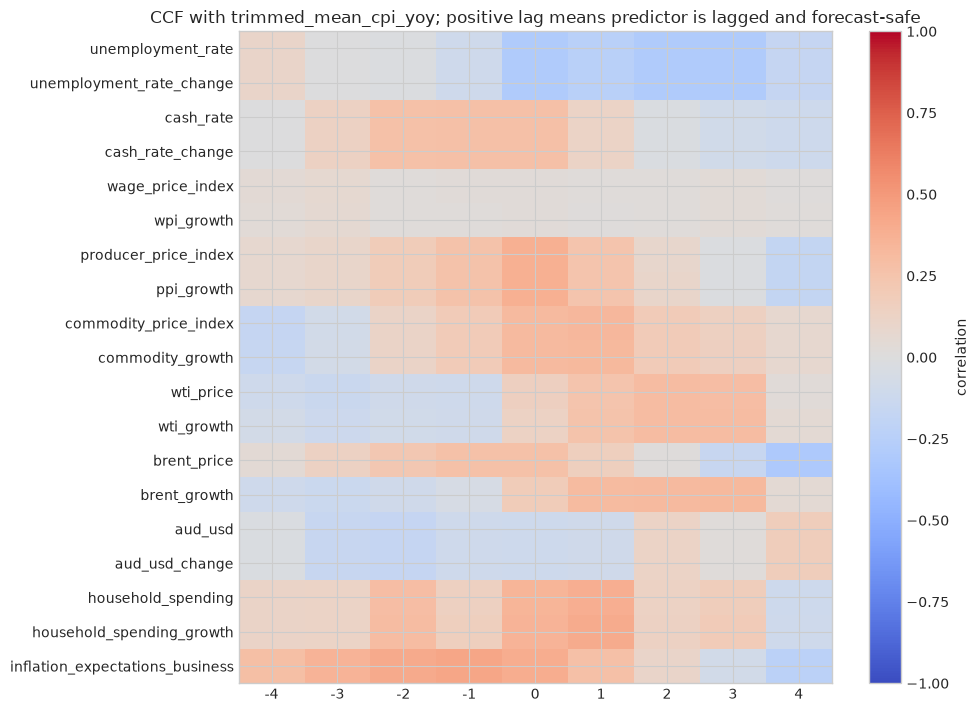

,target,variable,selected_lag,granger_p_value,min_granger_p_value,tested_lags,n_obs,note
11,trimmed_mean_cpi_yoy,wti_growth,3,0.0161,0.0145,"1:0.033, 2:0.014, 3:0.016, 4:0.041",101,screening signal only; not structural causality
10,trimmed_mean_cpi_yoy,wti_price,2,0.0240,0.0240,"1:0.058, 2:0.024, 3:0.031, 4:0.079",101,screening signal only; not structural causality
8,trimmed_mean_cpi_yoy,commodity_price_index,1,0.0315,0.0315,"1:0.031, 2:0.080, 3:0.084, 4:0.343",123,screening signal only; not structural causality
9,trimmed_mean_cpi_yoy,commodity_growth,1,0.0360,0.0360,"1:0.036, 2:0.091, 3:0.094, 4:0.360",123,screening signal only; not structural causality
13,trimmed_mean_cpi_yoy,brent_growth,3,0.0559,0.0372,"1:0.037, 2:0.048, 3:0.056, 4:0.153",73,screening signal only; not structural causality
0,trimmed_mean_cpi_yoy,unemployment_rate,3,0.0837,0.0837,"1:0.268, 2:0.101, 3:0.084, 4:0.147",123,screening signal only; not structural causality
1,trimmed_mean_cpi_yoy,unemployment_rate_change,3,0.0837,0.0837,"1:0.268, 2:0.101, 3:0.084, 4:0.147",123,screening signal only; not structural causality
17,trimmed_mean_cpi_yoy,household_spending_growth,1,0.1036,0.0948,"1:0.104, 2:0.166, 3:0.095, 4:0.193",53,screening signal only; not structural causality
16,trimmed_mean_cpi_yoy,household_spending,1,0.1316,0.1124,"1:0.132, 2:0.186, 3:0.112, 4:0.206",53,screening signal only; not structural causality
12,trimmed_mean_cpi_yoy,brent_price,4,0.3748,0.1552,"1:0.907, 2:0.165, 3:0.155, 4:0.375",74,screening signal only; not structural causality


,target,variable,lag_quarters,granger_p_value,n_obs
56,trimmed_mean_cpi_yoy,aud_usd,1,0.8129,63
57,trimmed_mean_cpi_yoy,aud_usd,2,0.1643,63
58,trimmed_mean_cpi_yoy,aud_usd,3,0.3035,63
59,trimmed_mean_cpi_yoy,aud_usd,4,0.4137,63
60,trimmed_mean_cpi_yoy,aud_usd_change,1,0.8105,63
...,...,...,...,...,...
47,trimmed_mean_cpi_yoy,wti_growth,4,0.0408,101
40,trimmed_mean_cpi_yoy,wti_price,1,0.0582,101
41,trimmed_mean_cpi_yoy,wti_price,2,0.0240,101
42,trimmed_mean_cpi_yoy,wti_price,3,0.0314,101


,target,candidate_feature,variable,candidate_lag,candidate_corr,candidate_abs_corr,candidate_granger_p_value,best_ccf_lag,best_ccf_corr,available_observations,coverage_pct
0,trimmed_mean_cpi_yoy,inflation_expectations_business_lag1,inflation_expectations_business,1,0.280,0.280,0.4600,1.0,0.280,124.0,1.000
1,trimmed_mean_cpi_yoy,ppi_growth_lag1,ppi_growth,1,0.246,0.246,0.6868,1.0,0.246,109.0,0.879
2,trimmed_mean_cpi_yoy,cash_rate_change_lag1,cash_rate_change,1,0.120,0.120,0.6177,1.0,0.120,123.0,0.992
3,trimmed_mean_cpi_yoy,unemployment_rate_change_lag1,unemployment_rate_change,1,-0.242,0.242,0.2675,3.0,-0.297,123.0,0.992
4,trimmed_mean_cpi_yoy,commodity_growth_lag1,commodity_growth,1,0.323,0.323,0.0360,1.0,0.323,123.0,0.992
5,trimmed_mean_cpi_yoy,wti_growth_lag1,wti_growth,1,0.255,0.255,0.0330,3.0,0.304,101.0,0.815
6,trimmed_mean_cpi_yoy,brent_growth_lag1,brent_growth,1,0.309,0.309,0.0372,3.0,0.321,73.0,0.589
7,trimmed_mean_cpi_yoy,wpi_growth_lag1,wpi_growth,1,0.009,0.009,0.8517,3.0,0.033,113.0,0.911
8,trimmed_mean_cpi_yoy,aud_usd_change_lag1,aud_usd_change,1,-0.099,0.099,0.8105,4.0,0.177,63.0,0.508
9,trimmed_mean_cpi_yoy,cash_rate_lag1,cash_rate,1,0.120,0.120,0.6177,1.0,0.120,124.0,1.000


,target,preferred_oil_feature_for_primary_vif,alternative_oil_feature,wti_growth_coverage_pct,brent_growth_coverage_pct,reason
0,trimmed_mean_cpi_yoy,wti_growth_lag1,brent_growth_lag1,0.815,0.589,WTI and Brent growth are alternative oil-price...


,target,primary_vif_feature
0,trimmed_mean_cpi_yoy,inflation_expectations_business_lag1
1,trimmed_mean_cpi_yoy,ppi_growth_lag1
2,trimmed_mean_cpi_yoy,cash_rate_change_lag1
3,trimmed_mean_cpi_yoy,unemployment_rate_change_lag1
4,trimmed_mean_cpi_yoy,commodity_growth_lag1
5,trimmed_mean_cpi_yoy,wti_growth_lag1
6,trimmed_mean_cpi_yoy,wpi_growth_lag1
7,trimmed_mean_cpi_yoy,aud_usd_change_lag1
8,trimmed_mean_cpi_yoy,cash_rate_lag1
9,trimmed_mean_cpi_yoy,covid_shock_rebound_lag1


,target,complete_rows_for_corr_vif,start_quarter,end_quarter
0,trimmed_mean_cpi_yoy,62,2010Q3,2025Q4


,inflation_expectations_business_lag1,ppi_growth_lag1,cash_rate_change_lag1,unemployment_rate_change_lag1,commodity_growth_lag1,wti_growth_lag1,wpi_growth_lag1,aud_usd_change_lag1,cash_rate_lag1,covid_shock_rebound_lag1,unemployment_rate_lag4
inflation_expectations_business_lag1,1.000,0.575,0.624,-0.306,0.130,0.077,0.117,-0.154,0.044,-0.183,-0.415
ppi_growth_lag1,0.575,1.000,0.413,-0.444,0.252,0.229,0.611,-0.175,0.128,-0.451,-0.315
cash_rate_change_lag1,0.624,0.413,1.000,-0.195,0.082,-0.061,0.259,-0.061,0.093,-0.142,-0.262
unemployment_rate_change_lag1,-0.306,-0.444,-0.195,1.000,-0.317,-0.448,-0.079,0.061,0.195,0.719,-0.306
commodity_growth_lag1,0.130,0.252,0.082,-0.317,1.000,0.249,-0.138,-0.139,-0.257,-0.080,0.280
wti_growth_lag1,0.077,0.229,-0.061,-0.448,0.249,1.000,-0.021,0.397,-0.170,-0.344,0.148
wpi_growth_lag1,0.117,0.611,0.259,-0.079,-0.138,-0.021,1.000,-0.011,0.497,-0.272,-0.404
aud_usd_change_lag1,-0.154,-0.175,-0.061,0.061,-0.139,0.397,-0.011,1.000,0.079,0.135,-0.039
cash_rate_lag1,0.044,0.128,0.093,0.195,-0.257,-0.170,0.497,0.079,1.000,-0.189,-0.566
covid_shock_rebound_lag1,-0.183,-0.451,-0.142,0.719,-0.080,-0.344,-0.272,0.135,-0.189,1.000,0.005


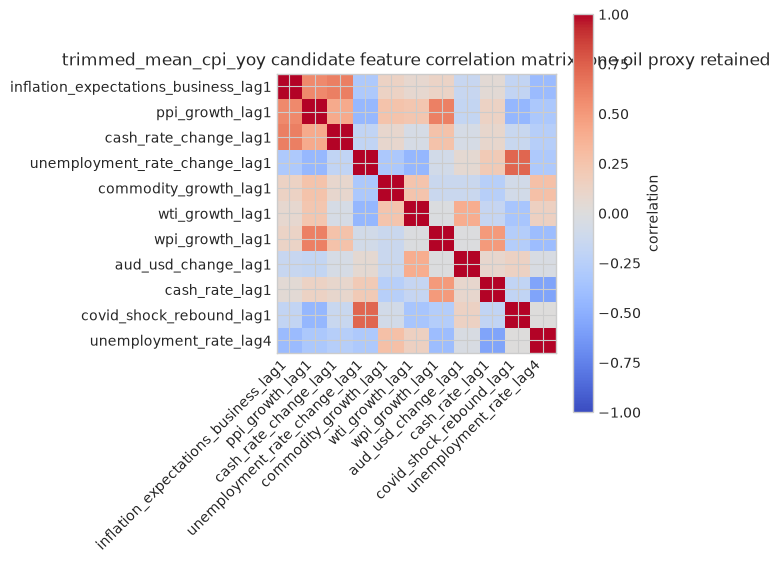

,candidate_feature,vif
6,wpi_growth_lag1,17.028
1,ppi_growth_lag1,10.161
10,unemployment_rate_lag4,9.353
0,inflation_expectations_business_lag1,8.808
8,cash_rate_lag1,7.258
3,unemployment_rate_change_lag1,3.562
9,covid_shock_rebound_lag1,3.452
5,wti_growth_lag1,1.975
2,cash_rate_change_lag1,1.780
7,aud_usd_change_lag1,1.661


,target,variable,candidate_feature,has_lag_feature,integration_order,best_ccf_lag,best_ccf_corr,candidate_lag,candidate_corr,candidate_abs_corr,candidate_granger_p_value,min_granger_p_value,vif,assumed_min_safe_lag_quarters,feature_lag_quarters,forecast_origin_safe_under_assumption,available_observations,coverage_pct,missing_pct,first_non_null,last_non_null,coverage_class,late_start_reduces_estimation_sample,substantial_missingness_warning,screening_status,reason
18,trimmed_mean_cpi_yoy,inflation_expectations_business,inflation_expectations_business_lag1,True,I(0),1,0.280,1.0,0.280,0.280,0.4600,0.0341,8.81,1,1.0,True,124,1.000,0.000,1995Q1,2025Q4,core_long_sample_candidate,False,False,candidate,candidate-lag CCF signal
4,trimmed_mean_cpi_yoy,wage_price_index,None,False,I(2),3,0.037,NaN,NaN,NaN,NaN,0.2189,NaN,1,NaN,False,114,0.919,0.081,1997Q3,2025Q4,shorter_sample_candidate,True,False,exclude,no lagged feature engineered in this notebook/...
6,trimmed_mean_cpi_yoy,producer_price_index,None,False,I(1),1,0.246,NaN,NaN,NaN,NaN,0.6409,NaN,1,NaN,False,110,0.887,0.113,1998Q3,2025Q4,shorter_sample_candidate,True,False,exclude,no lagged feature engineered in this notebook/...
8,trimmed_mean_cpi_yoy,commodity_price_index,None,False,I(1),1,0.329,NaN,NaN,NaN,NaN,0.0315,NaN,1,NaN,False,124,1.000,0.000,1995Q1,2025Q4,core_long_sample_candidate,False,False,exclude,no lagged feature engineered in this notebook/...
10,trimmed_mean_cpi_yoy,wti_price,None,False,I(1),2,0.303,NaN,NaN,NaN,NaN,0.0240,NaN,0,NaN,False,102,0.823,0.177,2000Q3,2025Q4,shorter_sample_candidate,True,False,exclude,no lagged feature engineered in this notebook/...
12,trimmed_mean_cpi_yoy,brent_price,None,False,I(0),4,-0.306,NaN,NaN,NaN,NaN,0.1552,NaN,0,NaN,False,74,0.597,0.403,2007Q3,2025Q4,limited_sample_candidate,True,True,exclude,no lagged feature engineered in this notebook/...
14,trimmed_mean_cpi_yoy,aud_usd,None,False,I(1),4,0.176,NaN,NaN,NaN,NaN,0.1643,NaN,0,NaN,False,64,0.516,0.484,2010Q1,2025Q4,limited_sample_candidate,True,True,exclude,no lagged feature engineered in this notebook/...
16,trimmed_mean_cpi_yoy,household_spending,None,False,I(1),1,0.385,NaN,NaN,NaN,NaN,0.1124,NaN,1,NaN,False,54,0.435,0.565,2012Q3,2025Q4,exclude_low_coverage,True,True,exclude,no lagged feature engineered in this notebook/...
17,trimmed_mean_cpi_yoy,household_spending_growth,None,True,I(0),1,0.400,NaN,NaN,NaN,NaN,0.0948,NaN,1,NaN,False,53,0.427,0.573,2012Q4,2025Q4,exclude_low_coverage,True,True,exclude,no candidate lag selected after availability/s...
0,trimmed_mean_cpi_yoy,unemployment_rate,unemployment_rate_lag4,True,I(1),3,-0.297,4.0,-0.165,0.165,0.1471,0.0837,9.35,1,4.0,True,124,1.000,0.000,1995Q1,2025Q4,core_long_sample_candidate,False,False,optional,weak candidate-lag CCF/Granger screening signal


Elastic Net candidate pool from trimmed-mean CPI EDA screening: inflation_expectations_business_lag1, brent_growth_lag1, unemployment_rate_change_lag1, ppi_growth_lag1, wti_growth_lag1, commodity_growth_lag1

These are not final feature-selection results. The modelling stage should compare a small set of nested Elastic Net feature specifications with walk-forward RMSE/MAE against seasonal-naive and SARIMA baselines, not exhaustive subset search on this small sample.

,variable,cpi_yoy_best_ccf_lag,cpi_yoy_best_ccf_corr,cpi_yoy_ccf_n_obs,cpi_yoy_selected_granger_p,cpi_yoy_min_granger_p,cpi_yoy_candidate_feature,cpi_yoy_candidate_corr,cpi_yoy_candidate_granger_p,cpi_yoy_screening_status,trimmed_mean_cpi_yoy_best_ccf_lag,trimmed_mean_cpi_yoy_best_ccf_corr,trimmed_mean_cpi_yoy_ccf_n_obs,trimmed_mean_cpi_yoy_selected_granger_p,trimmed_mean_cpi_yoy_min_granger_p,trimmed_mean_cpi_yoy_candidate_feature,trimmed_mean_cpi_yoy_candidate_corr,trimmed_mean_cpi_yoy_candidate_granger_p,trimmed_mean_cpi_yoy_screening_status,abs_best_ccf_corr_diff,selected_granger_signal_changed
7,commodity_price_index,2,0.2630,121,0.1873,0.0230,None,NaN,NaN,exclude,1,0.3287,122,0.0315,0.0315,None,NaN,NaN,exclude,0.0657,True
6,commodity_growth,2,0.2661,121,0.1850,0.0228,commodity_growth_lag1,0.2346,0.0228,strong candidate,1,0.3226,122,0.0360,0.0360,commodity_growth_lag1,0.3226,0.0360,strong candidate,0.0566,True
13,unemployment_rate,3,-0.3119,120,0.1780,0.0088,unemployment_rate_lag4,-0.2265,0.1817,candidate,3,-0.2967,120,0.0837,0.0837,unemployment_rate_lag4,-0.1652,0.1471,optional,-0.0151,True
14,unemployment_rate_change,3,-0.3119,120,0.1780,0.0088,unemployment_rate_change_lag1,-0.1657,0.0088,strong candidate,3,-0.2967,120,0.0837,0.0837,unemployment_rate_change_lag1,-0.2421,0.2675,optional/shorter-sample candidate,-0.0151,True
9,household_spending_growth,3,0.4941,50,0.0016,0.0016,None,NaN,NaN,exclude,1,0.4000,52,0.1036,0.0948,None,NaN,NaN,exclude,-0.0941,True
8,household_spending,3,0.4815,50,0.0037,0.0037,None,NaN,NaN,exclude,1,0.3854,52,0.1316,0.1124,None,NaN,NaN,exclude,-0.0961,True
12,producer_price_index,2,0.5550,107,0.0068,0.0068,None,NaN,NaN,exclude,1,0.2460,108,0.6842,0.6409,None,NaN,NaN,exclude,-0.3090,True
11,ppi_growth,2,0.5556,107,0.0066,0.0066,ppi_growth_lag2,0.5556,0.0066,strong candidate,1,0.2459,108,0.6868,0.6458,ppi_growth_lag1,0.2459,0.6868,optional/shorter-sample candidate,-0.3097,True
4,cash_rate,2,0.5112,121,0.0001,0.0000,cash_rate_lag2,0.5112,0.0001,strong candidate,1,0.1198,122,0.6177,0.3307,cash_rate_lag1,0.1198,0.6177,optional,-0.3914,True
5,cash_rate_change,2,0.5112,121,0.0001,0.0000,cash_rate_change_lag1,0.4967,0.0000,strong candidate,1,0.1198,122,0.6177,0.3307,cash_rate_change_lag1,0.1198,0.6177,optional,-0.3914,True


In [13]:
TRIMMED_MEAN_TARGET = 'trimmed_mean_cpi_yoy'
trimmed_correlation_base_cols = correlation_columns_for_target(TRIMMED_MEAN_TARGET, include_cpi_diagnostics=False)
trimmed_ccf, trimmed_best_predictive_ccf, trimmed_target_stationary = compute_lead_lag_correlation(
    TRIMMED_MEAN_TARGET,
    trimmed_correlation_base_cols,
)
display_lead_lag_correlation(TRIMMED_MEAN_TARGET, trimmed_correlation_base_cols, trimmed_ccf, trimmed_best_predictive_ccf)

trimmed_granger, trimmed_granger_lag_results, trimmed_best_lag_lookup = compute_granger_screens(
    TRIMMED_MEAN_TARGET,
    trimmed_correlation_base_cols,
    trimmed_target_stationary,
    trimmed_best_predictive_ccf,
)
display_granger_screens(trimmed_granger, trimmed_granger_lag_results)

trimmed_candidate_artifacts = build_target_candidate_artifacts(
    TRIMMED_MEAN_TARGET,
    trimmed_best_predictive_ccf,
    trimmed_ccf,
    trimmed_granger_lag_results,
    show_diagnostics=True,
)
trimmed_shortlist_artifacts = build_target_shortlist(
    TRIMMED_MEAN_TARGET,
    trimmed_candidate_artifacts,
    trimmed_best_predictive_ccf,
    trimmed_granger,
    'Elastic Net candidate pool from trimmed-mean CPI EDA screening',
    show_result=True,
)
trimmed_shortlist = trimmed_shortlist_artifacts['shortlist']
trimmed_chosen_feature_by_base = trimmed_shortlist_artifacts['chosen_feature_by_base']

def target_external_screen_summary(target: str, best_ccf_frame: pd.DataFrame, granger_frame: pd.DataFrame, shortlist_frame: pd.DataFrame) -> pd.DataFrame:
    best = best_ccf_frame.loc[best_ccf_frame['variable'].isin(EXTERNAL_BASE_COLS), ['variable', 'lag_quarters', 'correlation', 'n_obs']].copy()
    best = best.rename(columns={
        'lag_quarters': f'{target}_best_ccf_lag',
        'correlation': f'{target}_best_ccf_corr',
        'n_obs': f'{target}_ccf_n_obs',
    })
    granger_summary = granger_frame.loc[granger_frame['variable'].isin(EXTERNAL_BASE_COLS), ['variable', 'granger_p_value', 'min_granger_p_value']].copy()
    granger_summary = granger_summary.rename(columns={
        'granger_p_value': f'{target}_selected_granger_p',
        'min_granger_p_value': f'{target}_min_granger_p',
    })
    candidate_summary = shortlist_frame[['variable', 'candidate_feature', 'candidate_corr', 'candidate_granger_p_value', 'screening_status']].copy()
    candidate_summary = candidate_summary.rename(columns={
        'candidate_feature': f'{target}_candidate_feature',
        'candidate_corr': f'{target}_candidate_corr',
        'candidate_granger_p_value': f'{target}_candidate_granger_p',
        'screening_status': f'{target}_screening_status',
    })
    return best.merge(granger_summary, on='variable', how='outer').merge(candidate_summary, on='variable', how='outer')


headline_external_summary = target_external_screen_summary(TARGET, best_predictive_ccf, granger, shortlist)
trimmed_external_summary = target_external_screen_summary(TRIMMED_MEAN_TARGET, trimmed_best_predictive_ccf, trimmed_granger, trimmed_shortlist)
headline_vs_trimmed_screen = headline_external_summary.merge(trimmed_external_summary, on='variable', how='outer')
headline_vs_trimmed_screen['abs_best_ccf_corr_diff'] = (
    headline_vs_trimmed_screen[f'{TRIMMED_MEAN_TARGET}_best_ccf_corr'].abs()
    - headline_vs_trimmed_screen[f'{TARGET}_best_ccf_corr'].abs()
)
headline_vs_trimmed_screen['selected_granger_signal_changed'] = (
    headline_vs_trimmed_screen[f'{TARGET}_selected_granger_p'].le(SIGNAL_P_THRESHOLD)
    != headline_vs_trimmed_screen[f'{TRIMMED_MEAN_TARGET}_selected_granger_p'].le(SIGNAL_P_THRESHOLD)
)
display(
    headline_vs_trimmed_screen.sort_values(
        ['selected_granger_signal_changed', 'abs_best_ccf_corr_diff'],
        ascending=[False, False],
    ).round(4)
)

## 11. Rolling Correlations / Relationship Stability

This section checks whether CPI-predictor relationships are stable through time. It reuses the stationary transformations from the CCF section and applies forecast-safe lags where engineered lag features are available. These diagnostics are supplementary and are not fed back into the Section 10 include/exclude logic.

,variable,lag_used,rolling_windows,rolling_corr_min,rolling_corr_max,mean_abs_rolling_corr,rolling_corr_std,raw_sign_changes,strong_sign_changes,weak_window_share,covid_or_post_covid_only_signal,sign_change,rolling_relationship_stable,stability_warning,unstable_flag
15,wage_price_index,1,92,-0.110,0.282,0.063,0.072,26,0,0.957,False,False,False,weak in more than half of rolling windows,True
16,wpi_growth,2,91,-0.306,0.326,0.099,0.120,14,1,0.890,True,True,False,strong sign change; weak in more than half of ...,True
1,aud_usd_change,1,43,-0.477,0.463,0.176,0.229,5,1,0.605,False,True,False,strong sign change; weak in more than half of ...,True
18,wti_price,0,82,-0.456,0.485,0.187,0.222,10,2,0.573,False,True,False,strong sign change; weak in more than half of ...,True
13,unemployment_rate,4,100,-0.433,0.516,0.190,0.234,16,6,0.500,True,True,False,strong sign change; signal concentrated in COV...,True
17,wti_growth,1,81,-0.335,0.567,0.237,0.187,6,4,0.370,True,True,False,strong sign change; signal concentrated in COV...,True
14,unemployment_rate_change,1,103,-0.584,0.568,0.288,0.322,7,3,0.301,True,True,False,strong sign change; large rolling-correlation ...,True
0,aud_usd,0,44,-0.593,0.481,0.330,0.343,1,1,0.295,False,True,False,strong sign change; large rolling-correlation ...,True
5,cash_rate_change,1,103,-0.288,0.776,0.377,0.261,8,2,0.282,False,True,False,strong sign change,True
9,household_spending_growth,1,33,-0.006,0.514,0.302,0.130,2,0,0.242,True,False,False,signal concentrated in COVID/post-COVID period,True


period,covid,gfc,post_covid,post_gfc_pre_covid,pre_gfc
variable,,,,,
aud_usd,-0.62 (n=8),not tested,-0.27 (n=16),0.26 (n=39),not tested
aud_usd_change,-0.01 (n=8),not tested,-0.28 (n=16),0.28 (n=38),not tested
brent_growth,0.57 (n=8),not tested,0.12 (n=16),0.25 (n=42),not tested
brent_price,0.88 (n=8),not tested,0.64 (n=16),0.63 (n=42),not tested
cash_rate,0.38 (n=8),not tested,0.50 (n=16),0.33 (n=42),0.56 (n=51)
cash_rate_change,0.48 (n=8),not tested,0.77 (n=16),0.46 (n=42),0.42 (n=52)
commodity_growth,0.45 (n=8),not tested,0.27 (n=16),0.34 (n=42),0.30 (n=52)
commodity_price_index,0.43 (n=8),not tested,0.26 (n=16),0.34 (n=42),0.30 (n=52)
household_spending,0.00 (n=8),not tested,0.53 (n=16),0.19 (n=28),not tested


Short-regime correlations, especially GFC and COVID windows, can be based on very few quarterly observations, so period-specific correlations are indicative only. The instability flag uses strong sign changes after a correlation dead-band, weak rolling-correlation share, rolling variation, and crisis-period concentration.

,variable,candidate_feature,screening_status,rolling_relationship_stable,rolling_corr_min,rolling_corr_max,sign_change,stability_warning
0,unemployment_rate,unemployment_rate_lag4,candidate,False,-0.433,0.516,True,strong sign change; signal concentrated in COV...
1,wage_price_index,None,exclude,False,-0.110,0.282,False,weak in more than half of rolling windows
2,producer_price_index,None,exclude,False,-0.311,0.804,True,strong sign change
3,commodity_price_index,None,exclude,True,-0.013,0.690,False,
4,wti_price,None,exclude,False,-0.456,0.485,True,strong sign change; weak in more than half of ...
5,brent_price,None,exclude,True,-0.091,0.887,False,
6,aud_usd,None,exclude,False,-0.593,0.481,True,strong sign change; large rolling-correlation ...
7,household_spending,None,exclude,False,0.009,0.517,False,signal concentrated in COVID/post-COVID period
8,household_spending_growth,None,exclude,False,-0.006,0.514,False,signal concentrated in COVID/post-COVID period
9,aud_usd_change,aud_usd_change_lag1,optional,False,-0.477,0.463,True,strong sign change; weak in more than half of ...


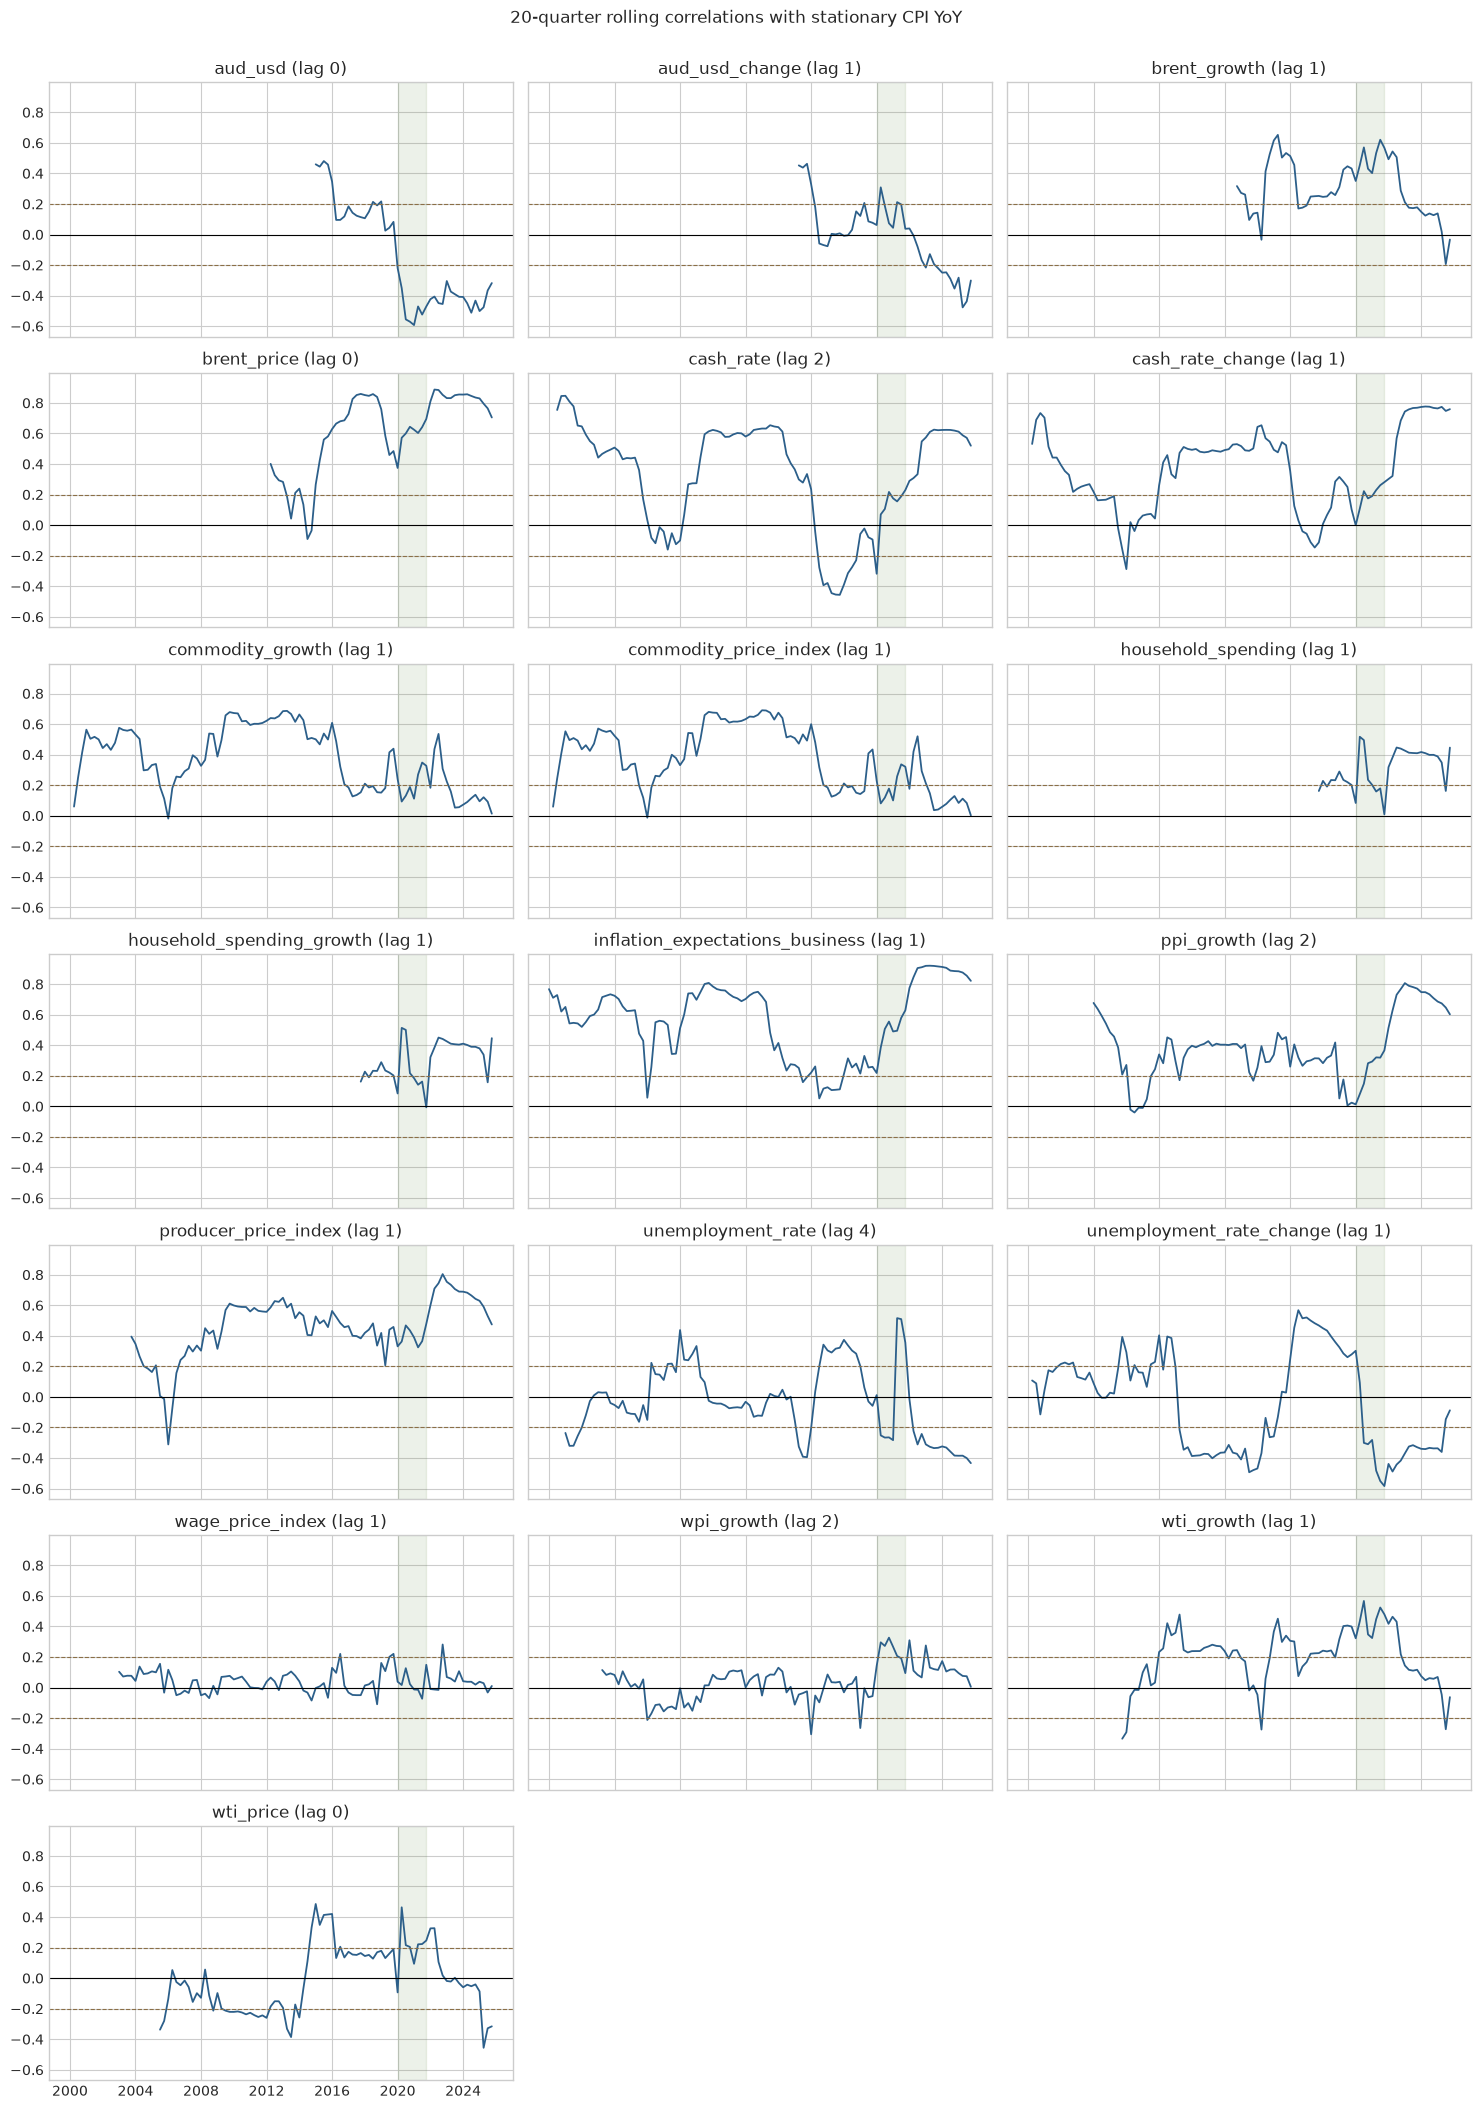

In [14]:
ROLLING_WINDOW = 20

def rolling_feature_lag(variable: str) -> int:
    chosen_feature = chosen_feature_by_base.get(variable)
    if chosen_feature is not None and pd.notna(feature_lag(chosen_feature)):
        return int(feature_lag(chosen_feature))
    return min_safe_lag_for_base(variable) if variable in availability_lookup else 0


def count_strong_sign_changes(corr: pd.Series, threshold: float) -> int:
    strong = corr.dropna()[corr.dropna().abs() >= threshold]
    signs = np.sign(strong)
    if len(signs) <= 1:
        return 0
    return int((signs != signs.shift()).sum() - 1)

rolling_corr_frames = []
period_rows = []
for variable in EXTERNAL_BASE_COLS:
    lag = rolling_feature_lag(variable)
    x_stationary = stationary_series(variable).rename(variable).shift(lag)
    aligned = pd.concat([target_stationary.rename(TARGET), x_stationary], axis=1).dropna()
    if len(aligned) < ROLLING_WINDOW:
        continue
    rolling_corr = aligned[TARGET].rolling(ROLLING_WINDOW).corr(aligned[variable]).dropna()
    rolling_corr_frames.append(pd.DataFrame({'quarter_period': rolling_corr.index, 'variable': variable, 'rolling_corr': rolling_corr.values, 'lag_used': lag}))

    periods = {
        'pre_gfc': aligned.index < pd.Period('2008Q3', freq='Q'),
        'gfc': (aligned.index >= pd.Period('2008Q3', freq='Q')) & (aligned.index <= pd.Period('2009Q2', freq='Q')),
        'post_gfc_pre_covid': (aligned.index >= pd.Period('2009Q3', freq='Q')) & (aligned.index < pd.Period('2020Q1', freq='Q')),
        'covid': (aligned.index >= pd.Period('2020Q1', freq='Q')) & (aligned.index <= pd.Period('2021Q4', freq='Q')),
        'post_covid': aligned.index >= pd.Period('2022Q1', freq='Q'),
    }
    for period_name, mask in periods.items():
        subset = aligned.loc[mask]
        period_rows.append({
            'variable': variable,
            'period': period_name,
            'lag_used': lag,
            'n_obs': int(len(subset)),
            'period_corr': subset[TARGET].corr(subset[variable]) if len(subset) >= 8 else np.nan,
        })

rolling_corrs = pd.concat(rolling_corr_frames, ignore_index=True) if rolling_corr_frames else pd.DataFrame(columns=['quarter_period', 'variable', 'rolling_corr', 'lag_used'])
period_correlation = pd.DataFrame(period_rows)

stability_rows = []
for variable, group in rolling_corrs.groupby('variable'):
    corr = group['rolling_corr'].dropna()
    signs = np.sign(corr.replace(0, np.nan)).dropna()
    raw_sign_changes = int((signs != signs.shift()).sum() - 1) if len(signs) > 1 else 0
    strong_sign_changes = count_strong_sign_changes(corr, SIGNAL_CORR_THRESHOLD)
    weak_share = float((corr.abs() < SIGNAL_CORR_THRESHOLD).mean()) if len(corr) else np.nan
    period_values = period_correlation.loc[period_correlation['variable'] == variable].set_index('period')['period_corr']
    pre_covid_abs_values = period_values.reindex(['pre_gfc', 'gfc', 'post_gfc_pre_covid']).abs().dropna()
    pre_abs = pre_covid_abs_values.max() if not pre_covid_abs_values.empty else np.nan
    covid_abs = abs(period_values.get('covid', np.nan))
    post_abs = abs(period_values.get('post_covid', np.nan))
    crisis_or_post_signal = (pd.notna(covid_abs) and covid_abs >= SIGNAL_CORR_THRESHOLD) or (pd.notna(post_abs) and post_abs >= SIGNAL_CORR_THRESHOLD)
    covid_or_post_only = bool(crisis_or_post_signal and (pd.isna(pre_abs) or pre_abs < SIGNAL_CORR_THRESHOLD))
    stability_rows.append({
        'variable': variable,
        'lag_used': int(group['lag_used'].iloc[0]),
        'rolling_windows': int(len(corr)),
        'rolling_corr_min': corr.min(),
        'rolling_corr_max': corr.max(),
        'mean_abs_rolling_corr': corr.abs().mean(),
        'rolling_corr_std': corr.std(),
        'raw_sign_changes': max(raw_sign_changes, 0),
        'strong_sign_changes': max(strong_sign_changes, 0),
        'weak_window_share': weak_share,
        'covid_or_post_covid_only_signal': covid_or_post_only,
        'sign_change': bool(max(strong_sign_changes, 0) > 0),
        'rolling_relationship_stable': not bool(max(strong_sign_changes, 0) > 0 or weak_share > 0.50 or corr.std() > 0.30 or covid_or_post_only),
        'stability_warning': '; '.join([reason for condition, reason in [
            (max(strong_sign_changes, 0) > 0, 'strong sign change'),
            (weak_share > 0.50, 'weak in more than half of rolling windows'),
            (corr.std() > 0.30, 'large rolling-correlation variation'),
            (covid_or_post_only, 'signal concentrated in COVID/post-COVID period'),
        ] if condition]),
        'unstable_flag': bool(max(strong_sign_changes, 0) > 0 or weak_share > 0.50 or corr.std() > 0.30 or covid_or_post_only),
    })

stability_summary = pd.DataFrame(stability_rows).sort_values(['unstable_flag', 'weak_window_share', 'rolling_corr_std'], ascending=[False, False, False])
display(stability_summary.round(3))

period_display = period_correlation.copy()
period_display['corr_with_n'] = period_display.apply(
    lambda row: 'not tested' if pd.isna(row['period_corr']) else f"{row['period_corr']:.2f} (n={int(row['n_obs'])})",
    axis=1,
)
display(period_display.pivot(index='variable', columns='period', values='corr_with_n'))
display(Markdown('Short-regime correlations, especially GFC and COVID windows, can be based on very few quarterly observations, so period-specific correlations are indicative only. The instability flag uses strong sign changes after a correlation dead-band, weak rolling-correlation share, rolling variation, and crisis-period concentration.'))

shortlist_with_stability = shortlist.merge(
    stability_summary[['variable', 'rolling_relationship_stable', 'rolling_corr_min', 'rolling_corr_max', 'sign_change', 'stability_warning']],
    on='variable',
    how='left',
)
display(shortlist_with_stability[['variable', 'candidate_feature', 'screening_status', 'rolling_relationship_stable', 'rolling_corr_min', 'rolling_corr_max', 'sign_change', 'stability_warning']].round({'rolling_corr_min': 3, 'rolling_corr_max': 3}))

if not rolling_corrs.empty:
    n_cols = 3
    n_rows = int(np.ceil(rolling_corrs['variable'].nunique() / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3.0 * n_rows)), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    for ax, (variable, group) in zip(axes, rolling_corrs.groupby('variable')):
        plot_dates = pd.PeriodIndex(group['quarter_period'], freq='Q').to_timestamp(how='start')
        ax.plot(plot_dates, group['rolling_corr'], color='#2c5f8a', linewidth=1.3)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axhline(SIGNAL_CORR_THRESHOLD, color='#8b6f47', linestyle='--', linewidth=0.8)
        ax.axhline(-SIGNAL_CORR_THRESHOLD, color='#8b6f47', linestyle='--', linewidth=0.8)
        ax.axvspan(pd.Period('2020Q1', freq='Q').to_timestamp(), pd.Period('2021Q4', freq='Q').to_timestamp(), color='#6a8f4e', alpha=0.12)
        ax.set_title(f'{variable} (lag {int(group["lag_used"].iloc[0])})')
    for ax in axes[rolling_corrs['variable'].nunique():]:
        ax.axis('off')
    fig.suptitle(f'{ROLLING_WINDOW}-quarter rolling correlations with stationary CPI YoY', y=1.002)
    fig.tight_layout()
    plt.show()

## 12. Raw Source Frequency Validation Spot Check

The notebook primarily validates the curated quarterly modelling table. This light spot check reconciles two representative raw inputs against the curated quarterly values using the ETL rule in `src.transform.to_quarterly()` and the source-specific aggregation configured in `src.build_curated_dataset.SeriesSpec`. It is not a full raw-source audit.

In [15]:
from src.transform import to_quarterly
from src.validation import find_date_column

spot_specs = [
    {
        'variable': 'cash_rate',
        'source_family': 'RBA cash rate',
        'source_frequency': 'monthly',
        'path': latest_dataset_path(ROOT / 'dataset' / 'rba' / 'cash_rate_1995_2026.csv'),
        'value_col': 'cash_rate',
        'agg': 'mean',
    },
    {
        'variable': 'wti_price',
        'source_family': 'market WTI crude oil',
        'source_frequency': 'daily trading days',
        'path': latest_dataset_path(ROOT / 'dataset' / 'market' / 'wti_crude_oil_1995_2025.csv'),
        'value_col': 'Close',
        'agg': 'mean',
    },
]

spot_rows = []
frequency_rows = []
curated_lookup = df_model.set_index('quarter')
for spec in spot_specs:
    raw = pd.read_csv(spec['path'])
    date_col = find_date_column(raw)
    raw_quarters = pd.to_datetime(raw[date_col], errors='coerce').dt.to_period('Q')
    raw = raw.loc[raw_quarters.isna() | (raw_quarters <= EDA_END_QUARTER)]
    parsed_dates = pd.to_datetime(raw[date_col], errors='coerce')
    parsed_non_null = parsed_dates.dropna().sort_values()
    inferred_frequency = pd.infer_freq(parsed_non_null.head(12)) if len(parsed_non_null) >= 12 else None
    median_spacing_days = parsed_non_null.diff().dt.days.dropna().median() if len(parsed_non_null) > 1 else np.nan
    duplicate_dates = int(parsed_dates.duplicated().sum())

    frequency_rows.append({
        'variable': spec['variable'],
        'source_family': spec['source_family'],
        'source_frequency': spec['source_frequency'],
        'raw_rows': int(len(raw)),
        'date_col': date_col,
        'start_date': parsed_non_null.min().date() if len(parsed_non_null) else None,
        'end_date': parsed_non_null.max().date() if len(parsed_non_null) else None,
        'duplicate_dates': duplicate_dates,
        'inferred_frequency_head': inferred_frequency,
        'median_spacing_days': median_spacing_days,
    })

    quarterly = to_quarterly(raw, value_col=spec['value_col'], output_col=spec['variable'], agg=spec['agg'], date_col=date_col)
    common_quarters = [quarter for quarter in quarterly['quarter'] if quarter in curated_lookup.index and pd.notna(curated_lookup.loc[quarter, spec['variable']])]
    sample_quarters = []
    if common_quarters:
        sample_quarters.append(common_quarters[0])
    if len(common_quarters) > 1:
        sample_quarters.append(common_quarters[len(common_quarters) // 2])
    for quarter in dict.fromkeys(sample_quarters):
        raw_value = float(quarterly.loc[quarterly['quarter'] == quarter, spec['variable']].iloc[0])
        curated_value = float(curated_lookup.loc[quarter, spec['variable']])
        spot_rows.append({
            'variable': spec['variable'],
            'source_frequency': spec['source_frequency'],
            'aggregation_rule': spec['agg'],
            'spot_quarter': quarter,
            'raw_derived_value': raw_value,
            'curated_value': curated_value,
            'absolute_difference': abs(raw_value - curated_value),
            'match': bool(np.isclose(raw_value, curated_value, rtol=1e-8, atol=1e-8)),
        })

raw_frequency_spot_check = pd.DataFrame(frequency_rows)
raw_curated_reconciliation = pd.DataFrame(spot_rows)
display(raw_frequency_spot_check)
display(raw_curated_reconciliation.round({'raw_derived_value': 6, 'curated_value': 6, 'absolute_difference': 10}))

display(Markdown('This spot check verifies representative monthly and daily inputs only. Full source-level validation remains an ETL/data-quality task; this EDA validates the curated quarterly table used for modelling.'))

,variable,source_family,source_frequency,raw_rows,date_col,start_date,end_date,duplicate_dates,inferred_frequency_head,median_spacing_days
0,cash_rate,RBA cash rate,monthly,372,date,1995-01-01,2025-12-01,0,MS,31.0
1,wti_price,market WTI crude oil,daily trading days,6367,Date,2000-08-23,2025-12-31,0,None,1.0


,variable,source_frequency,aggregation_rule,spot_quarter,raw_derived_value,curated_value,absolute_difference,match
0,cash_rate,monthly,mean,1995Q1,7.500000,7.500000,0.0,True
1,cash_rate,monthly,mean,2010Q3,4.500000,4.500000,0.0,True
2,wti_price,daily trading days,mean,2000Q3,33.527407,33.527407,0.0,True
3,wti_price,daily trading days,mean,2013Q2,94.173281,94.173281,0.0,True


This spot check verifies representative monthly and daily inputs only. Full source-level validation remains an ETL/data-quality task; this EDA validates the curated quarterly table used for modelling.

## 14. RBA Forecast Error Benchmark Preparation

This section uses the newly retrieved RBA historical CPI forecast file as a benchmark-preparation diagnostic. It summarises forecast errors by published horizon only; formal model comparison still belongs in the rolling-origin modelling stage, where SARIMA/Elastic Net/Ensemble forecasts can be aligned to the same horizons.


,horizon_quarters,n_forecasts,start_forecast_date,end_forecast_date,mean_error,mae,rmse
0,0,121,1995-03-01,2025-02-01,-0.018,0.207,0.287
1,1,121,1995-03-01,2025-02-01,-0.022,0.436,0.601
2,2,121,1995-03-01,2025-02-01,-0.025,0.633,0.894
3,3,121,1995-03-01,2025-02-01,-0.059,0.845,1.197
4,4,120,1995-03-01,2024-11-01,-0.065,1.012,1.419
5,5,119,1995-03-01,2024-08-01,-0.050,1.110,1.555
6,6,113,1995-06-01,2024-05-01,0.013,1.139,1.619
7,7,94,1995-06-01,2024-02-01,0.041,1.203,1.727
8,8,75,1995-06-01,2023-11-01,0.163,1.253,1.823
9,9,43,1998-03-01,2023-08-01,0.216,1.184,1.686


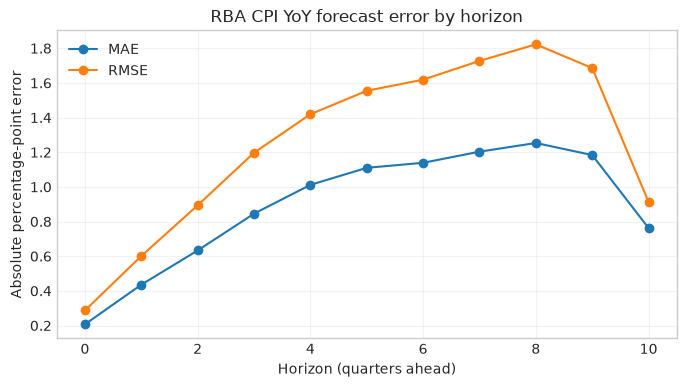

RBA forecast errors are summarised as percentage-point CPI YoY forecast errors. Use these horizon-level MAE/RMSE values as benchmark context only until model forecasts are generated on the same forecast-origin and horizon grid.

In [16]:
RBA_FORECAST_PATH = latest_dataset_path(ROOT / 'dataset' / 'rba' / 'rba_historical_cpi_forecasts_by_horizon_1995_2026.csv')

if RBA_FORECAST_PATH.exists():
    rba_forecasts = pd.read_csv(RBA_FORECAST_PATH)
    rba_forecasts['forecast_date'] = pd.to_datetime(rba_forecasts['forecast_date'], errors='coerce')
    rba_eval = rba_forecasts.loc[
        rba_forecasts['horizon_quarters'].ge(0)
        & rba_forecasts['rba_forecast_cpi_yoy'].notna()
        & rba_forecasts['rba_actual_cpi_yoy'].notna()
    ].copy()
    if 'rba_forecast_error_cpi_yoy' not in rba_eval or rba_eval['rba_forecast_error_cpi_yoy'].isna().all():
        rba_eval['rba_forecast_error_cpi_yoy'] = rba_eval['rba_actual_cpi_yoy'] - rba_eval['rba_forecast_cpi_yoy']
    rba_eval = rba_eval.loc[rba_eval['rba_forecast_error_cpi_yoy'].notna()].copy()
    rba_target_quarter = rba_eval['forecast_date'].dt.to_period('Q') + rba_eval['horizon_quarters'].astype(int)
    rba_eval = rba_eval.loc[rba_target_quarter <= EDA_END_QUARTER].copy()

    rba_horizon_error = (
        rba_eval.groupby('horizon_quarters')
        .agg(
            n_forecasts=('rba_forecast_error_cpi_yoy', 'size'),
            start_forecast_date=('forecast_date', 'min'),
            end_forecast_date=('forecast_date', 'max'),
            mean_error=('rba_forecast_error_cpi_yoy', 'mean'),
            mae=('rba_forecast_error_cpi_yoy', lambda s: s.abs().mean()),
            rmse=('rba_forecast_error_cpi_yoy', lambda s: np.sqrt(np.mean(np.square(s)))),
        )
        .reset_index()
    )
    rba_horizon_error['start_forecast_date'] = rba_horizon_error['start_forecast_date'].dt.strftime('%Y-%m-%d')
    rba_horizon_error['end_forecast_date'] = rba_horizon_error['end_forecast_date'].dt.strftime('%Y-%m-%d')
    display(rba_horizon_error.round({'mean_error': 3, 'mae': 3, 'rmse': 3}))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(rba_horizon_error['horizon_quarters'], rba_horizon_error['mae'], marker='o', label='MAE')
    ax.plot(rba_horizon_error['horizon_quarters'], rba_horizon_error['rmse'], marker='o', label='RMSE')
    ax.set_title('RBA CPI YoY forecast error by horizon')
    ax.set_xlabel('Horizon (quarters ahead)')
    ax.set_ylabel('Absolute percentage-point error')
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()

    display(Markdown('RBA forecast errors are summarised as percentage-point CPI YoY forecast errors. Use these horizon-level MAE/RMSE values as benchmark context only until model forecasts are generated on the same forecast-origin and horizon grid.'))
else:
    rba_horizon_error = pd.DataFrame()
    display(Markdown('RBA historical CPI forecast data is not present, so RBA forecast-error benchmarking remains blocked until the source file is retrieved.'))


## 13. Documented Limitations And Follow-Ups

- **Historical RBA forecast error review:** Section 14 now summarises RBA historical CPI forecast errors by horizon from `dataset/rba/rba_historical_cpi_forecasts_by_horizon_1995_2026.csv`. It is benchmark preparation only; final model comparison still needs rolling-origin SARIMA/Elastic Net/Ensemble forecasts aligned to the same forecast dates and horizons.
- **Trimmed-mean CPI as a CPI-family diagnostic, not current Elastic Net exogenous plan:** In the executed stationarity table, headline `cpi_yoy` is classified as `I(0)` with level ADF p=0.0299 and KPSS p=0.1000, while `trimmed_mean_cpi_yoy` is classified as `I(1)` because its level ADF p=0.1896 does not reject a unit root even though KPSS p=0.1000 does not reject stationarity; first differences pass both tests with ADF p=0.0000 and KPSS p=0.1000. Lead-lag diagnostics show `trimmed_mean_cpi_yoy` has its strongest positive-lag correlation with headline `cpi_yoy` at lag 2 (corr=0.4773, n=121), and the available `trimmed_mean_cpi_yoy_lag1` feature has corr=0.4400. Granger screening is significant for `trimmed_mean_cpi_yoy` at the selected lag 2 (p=0.0234) and at lag 1 (p=0.0016). The CPI-lag VIF table is below the 10 threshold but not negligible: `trimmed_mean_cpi_yoy_lag1` VIF=3.427, `cpi_yoy_lag1` VIF=2.490, and `cpi_yoy_lag4` VIF=1.854. These numbers do not rule out lagged trimmed-mean YoY as a forecast-safe Elastic Net regressor if release timing is explicitly handled, but because it is an alternative CPI measure rather than an ordinary external macro indicator, the current plan keeps it out of the generic exogenous pool and treats trimmed-mean inflation primarily as a separate modelling target. The headline-minus-trimmed-mean gap is worth follow-up but is mixed rather than decisive: its best positive-lag correlation is high at lag 1 (corr=0.6592, n=123), but Granger p=0.8141 at that same lag, with only the minimum across tested lags reaching p=0.0359.
- **Independent trimmed-mean target screening:** Section 10b now reruns the external-macro CCF, Granger, VIF, and shortlist logic with `trimmed_mean_cpi_yoy` as the target. The executed comparison shows a materially different candidate mix from headline `cpi_yoy`: headline's strongest external signals are `inflation_expectations_business_lag1` (best corr=0.7407, Granger p=0.0000), `ppi_growth_lag2` (corr=0.5556, p=0.0066), `cash_rate_lag2`/`cash_rate_change_lag1` (best corr=0.5112, p=0.0001/0.0000), plus oil and commodity lags. For trimmed mean, those headline demand/policy/expectations signals weaken sharply: inflation expectations fall to corr=0.2803 with Granger p=0.4600, PPI to corr=0.2459 with p=0.6868, and cash-rate/cash-rate-change to corr=0.1198 with p=0.6177. The trimmed-mean pool is instead led by `commodity_growth_lag1` (corr=0.3226, p=0.0360) and `wti_growth_lag1` (best corr=0.3039, candidate corr=0.2552, p=0.0330), with `brent_growth_lag1` retained only as the shorter-sample alternative oil proxy (corr=0.3088, p=0.0372). `unemployment_rate_change_lag1` and `ppi_growth_lag1` retain CCF signal but weak candidate-lag Granger evidence (p=0.2675 and p=0.6868), so they look like optional/diagnostic additions rather than core trimmed-mean regressors. This implies the eventual trimmed-mean Elastic Net refit should not blindly reuse the headline exogenous group; it should start from a smaller commodity/oil-led specification and test expectations/PPI/cash-rate terms only as nested alternatives. Section 11 rolling-correlation stability remains headline-only in this notebook pass.

- **Growth-rate STL replacement for removed CPI index:** The STL decomposition now runs on headline `cpi_yoy`, not a CPI level index. The executed strength table shows headline `cpi_yoy` seasonal strength=0.000 and trend strength=0.842, while `trimmed_mean_cpi_yoy` has seasonal strength=0.000 and trend strength=0.875; this reads as a trend-dominated growth-rate decomposition, not evidence about seasonality in the removed level index.
- **Feature-pipeline follow-up:** `src.features` now owns the rate-change and lag definitions surfaced by this EDA. Regenerate `data/curated/quarterly_macro_features.*` before modelling so Elastic Net code consumes the same `cash_rate_change_lag1`, `unemployment_rate_change_lag1`, and household-spending-growth lag features that the notebook screens.
- **Release calendar metadata and real-time vintages:** `data/metadata/series_availability.csv` is an assumption-backed forecast-origin lag table, not official ABS/RBA release-calendar metadata. The current curated dataset uses revised historical observations, not full real-time vintage data. Before live forecast-origin decisions, replace or verify it with observation-level release dates and `available_at_forecast_origin` fields.
